## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



### One-Stop AI Solutions for Modulation Design of DAB Converters
 * Preparetion: Exploratory data analysis
   1. Histogram
   2. Correlation map
   3. t-SNE and explain the feature distribution
   4. Conduct PCA on variables D0, D1, D2, Vref, and PL
 * Stage 1: Outlier detection and data cleaning with one-class SVM
 * Stage 2: Data-driven performance modeling with NNs
   1. Neural networks
   2. Benchmark with ensemble learning algorithms
* Stage 3: Meta-heuristic algorithms to optimize converter performance
   1. PSO
   2. GA
* Stage 4: TinyML as online adaptive modulator to adjust optimal modulation parameters given operating conditions

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Parepartion - Exploratory Data Analysis
* Histogram
* Correlation map
* t-SNE and explain the feature distribution
* Conduct PCA on variables D0, D1, D2, Vref, and PL

##### 1.1 Load Data of Performance Modeling for DAB Converters

In [2]:
import pandas as pd
import numpy as np

# Load the CSV file into a DataFrame, using the first column as the index
df = pd.read_csv("DAB_TPS.csv", index_col=0)

# Print the initial shape of the DataFrame (rows, columns)
print("Initial shape:", df.shape)

#------------------------------------------------------------------------------------------------
# Conduct basic data cleaning
#------------------------------------------------------------------------------------------------
# Filter out rows where the "Validity" column is 0 (i.e., keep only valid samples)
df_filtered = df[df['Validity'] != 0]

# List of columns representing ZVS (Zero Voltage Switching) status for primary and secondary sides
sum_columns = ["vp_t1", "vp_t2", "vp_t3", "vp_t4", "vs_t1", "vs_t2", "vs_t3", "vs_t4"]

# Create a new column 'total_ZVS' as the sum of the ZVS status columns for each row
df_filtered['total_ZVS'] = df_filtered[sum_columns].sum(axis=1)

# Filter out samples where the sum of ZVS status is odd (i.e., keep only even sums)
df_final = df_filtered[df_filtered['total_ZVS'] % 2 == 0]

#-------------------------------
# Analyze outliers in the 'ipk2pk' feature
#-------------------------------
# Extract the 'ipk2pk' column for analysis
ipk2pk = df_final['ipk2pk']

# Calculate the mean and standard deviation of 'ipk2pk'
mean_ipk2pk = ipk2pk.mean()
std_ipk2pk = ipk2pk.std()

# Define outlier thresholds as 3 standard deviations from the mean
upper_threshold = mean_ipk2pk + 3 * std_ipk2pk
lower_threshold = mean_ipk2pk - 3 * std_ipk2pk

# Identify outliers: samples where 'ipk2pk' is outside the threshold range
outliers = df_final[(ipk2pk > upper_threshold) | (ipk2pk < lower_threshold)]

# Print statistics and outlier information
print(f"ipk2pk mean: {mean_ipk2pk:.3f}, std: {std_ipk2pk:.3f}")
print(f"Outlier threshold: < {lower_threshold:.3f} or > {upper_threshold:.3f}")
print(f"Number of outliers in ipk2pk: {outliers.shape[0]}")


Initial shape: (5291, 18)
ipk2pk mean: 13.303, std: 5.266
Outlier threshold: < -2.495 or > 29.102
Number of outliers in ipk2pk: 0


##### 1.2 Histogram and Correlation Map

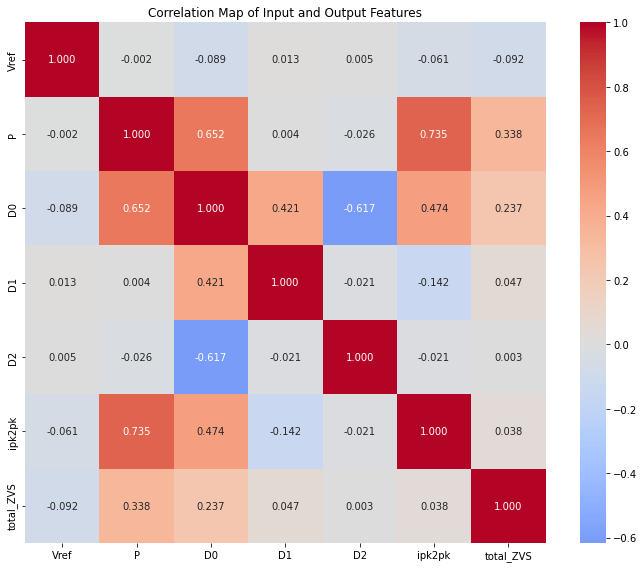

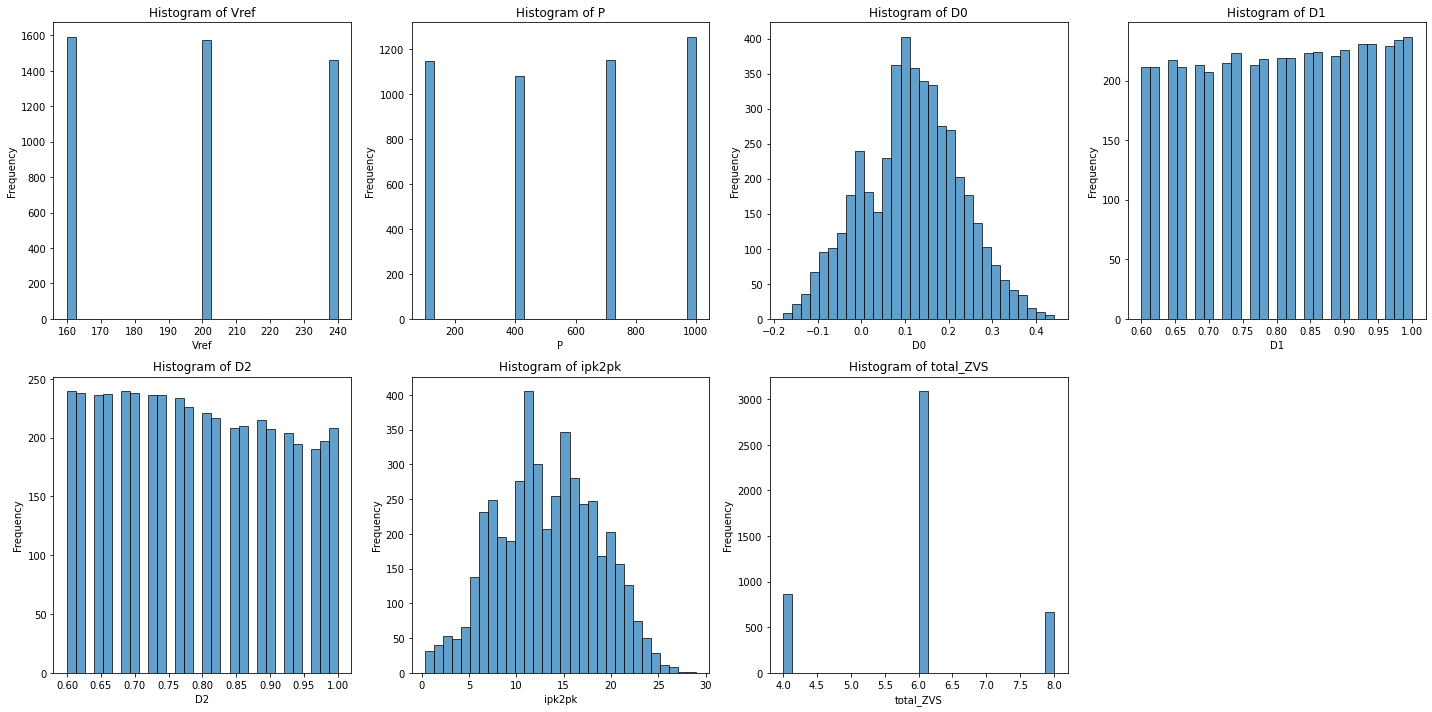

=== BASIC DATA ANALYSIS ===
Total number of samples: 4633

=== FEATURE STATISTICS ===
              Vref            P           D0           D1           D2  \
count  4633.000000  4633.000000  4633.000000  4633.000000  4633.000000   
mean    198.860350   562.788690     0.115350     0.804118     0.791604   
std      32.470202   340.236625     0.107296     0.121462     0.120520   
min     160.000000   100.000000    -0.178947     0.600000     0.600000   
25%     160.000000   400.000000     0.040641     0.700000     0.680000   
50%     200.000000   700.000000     0.119363     0.800000     0.780000   
75%     240.000000  1000.000000     0.181829     0.920000     0.900000   
max     240.000000  1000.000000     0.440729     1.000000     1.000000   

            ipk2pk    total_ZVS  
count  4633.000000  4633.000000  
mean     13.303469     5.915821  
std       5.266241     1.149751  
min       0.368701     4.000000  
25%       9.556965     6.000000  
50%      13.193537     6.000000  
75%      

In [3]:
import matplotlib.pyplot as plt  # For plotting histograms and other visualizations
import seaborn as sns  # For enhanced statistical data visualization

# Define the input features to be analyzed (control and system parameters)
input_features = ["Vref", "P", "D0", "D1", "D2"]
# input_features = ["Vin", "Vref", "P", "D0", "D1", "D2"]

# Define the output features to be analyzed (measured or derived quantities)
output_features = ["ipk2pk", "total_ZVS"]

# Combine input and output features for comprehensive analysis
all_features = input_features + output_features

#------------------------------------------------------------------------------------------------
# Conduct basic data analysis, including correlation map, histograms, feature ranges, etc.
#------------------------------------------------------------------------------------------------

# Import utility functions for plotting and statistical analysis
from utils import plot_correlation_map, plot_feature_histograms, basic_statistical_analysis

# 1. Correlation Map: Visualize pairwise correlations between selected features
plot_correlation_map(df_final, all_features)

# 2. Histograms: Plot the distribution of each feature to understand their spread and outliers
plot_feature_histograms(df_final, all_features)

# 3. Basic Statistical Analysis: Print summary statistics (mean, std, min, max, etc.) for each feature
basic_statistical_analysis(df_final, all_features)


##### 1.3 t-SNE Analysis

In [ ]:
# t-SNE Visualization for Input, Output, and Combined Features

# Import necessary libraries for t-SNE and plotting
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for t-SNE analysis
# Extract input features as a numpy array
input_data = df_final[input_features].values
# Extract output features as a numpy array
output_data = df_final[output_features].values
# Combine input and output features for joint analysis
combined_data = df_final[input_features + output_features].values

# Get unique voltage levels for coloring the t-SNE plots
voltage_levels = df_final['Vref'].unique()
# Generate a color for each voltage level using a colormap
voltage_colors = plt.cm.Set1(np.linspace(0, 1, len(voltage_levels)))
# Create a mapping from voltage level to color
voltage_color_map = dict(zip(voltage_levels, voltage_colors))

#------------------------------------------------------------------------------------------------
# Conduct t-SNE analysis for three cases:
#   1) Input features only
#   2) Output features only
#   3) Combined input and output features
#------------------------------------------------------------------------------------------------

# 1. t-SNE for Input Features
print("Computing t-SNE for input features...")
# Initialize t-SNE with 2 components, fixed random state, and specified perplexity
tsne_input = TSNE(n_components=2, random_state=42, perplexity=200)
# Fit and transform the input data
input_tsne = tsne_input.fit_transform(input_data)

# 2. t-SNE for Output Features
print("Computing t-SNE for output features...")
# Initialize t-SNE for output features
tsne_output = TSNE(n_components=2, random_state=42, perplexity=200)
# Fit and transform the output data
output_tsne = tsne_output.fit_transform(output_data)

# 3. t-SNE for Combined Features
print("Computing t-SNE for combined features...")
# Initialize t-SNE for combined features
tsne_combined = TSNE(n_components=2, random_state=42, perplexity=200)
# Fit and transform the combined data
combined_tsne = tsne_combined.fit_transform(combined_data)

# Import the function to plot the t-SNE analysis from the utils module
from utils import plot_tsne_analysis

print("Plotting t-SNE analysis...")
# Plot the t-SNE results for input, output, and combined features
plot_tsne_analysis(
    df_final,                # DataFrame containing all data
    voltage_levels,          # Unique voltage levels for coloring
    voltage_color_map,       # Mapping from voltage level to color
    input_tsne,              # t-SNE results for input features
    output_tsne,             # t-SNE results for output features
    combined_tsne,           # t-SNE results for combined features
    input_features,          # List of input feature names
    output_features,         # List of output feature names
)

In [ ]:
# t-SNE Visualization for Input, Output, and Combined Features

# Import necessary libraries for plotting and numerical operations
import matplotlib.pyplot as plt
import numpy as np

# Prepare data arrays for t-SNE analysis
# Extract input features from the DataFrame
input_data = df_final[input_features].values
# Extract output features from the DataFrame
output_data = df_final[output_features].values
# Combine input and output features for joint analysis
combined_data = df_final[input_features + output_features].values

#------------------------------------------------------------------------------------------------
# Use unique voltage and power levels to color the t-SNE analysis
#------------------------------------------------------------------------------------------------

# Get unique voltage levels from the 'Vref' column for coloring
voltage_levels = df_final['Vref'].unique()
# Get unique power levels from the 'P' column for coloring
power_levels = df_final['P'].unique()
# Generate a color map for voltage levels using the Set1 colormap
voltage_colors = plt.cm.Set1(np.linspace(0, 1, len(voltage_levels)))
# Generate a color map for power levels using the tab10 colormap
power_colors = plt.cm.tab10(np.linspace(0, 1, len(power_levels)))
# Create a mapping from voltage level to color
voltage_color_map = dict(zip(voltage_levels, voltage_colors))
# Create a mapping from power level to color
power_color_map = dict(zip(power_levels, power_colors))

# Import the function to plot the t-SNE analysis from the utils module
from utils import plot_tsne_analysis

print("Plotting t-SNE analysis...")
# Plot the t-SNE analysis, colored by voltage and power levels
plot_tsne_analysis(
    df_final,                # DataFrame containing all data
    voltage_levels,          # Unique voltage levels for coloring
    voltage_color_map,       # Mapping from voltage level to color
    input_tsne,              # t-SNE results for input features
    output_tsne,             # t-SNE results for output features
    combined_tsne,           # t-SNE results for combined features
    input_features,          # List of input feature names
    output_features,         # List of output feature names
    power_levels=power_levels,       # Unique power levels for coloring
    power_color_map=power_color_map  # Mapping from power level to color
)


##### 9.1.4 Implement PCA for Variables D0, D1, D2, PL, and Vref
* These 5 variables satisfy an equation. 
* Let's use PCA to find it out "Data-drivenly"!

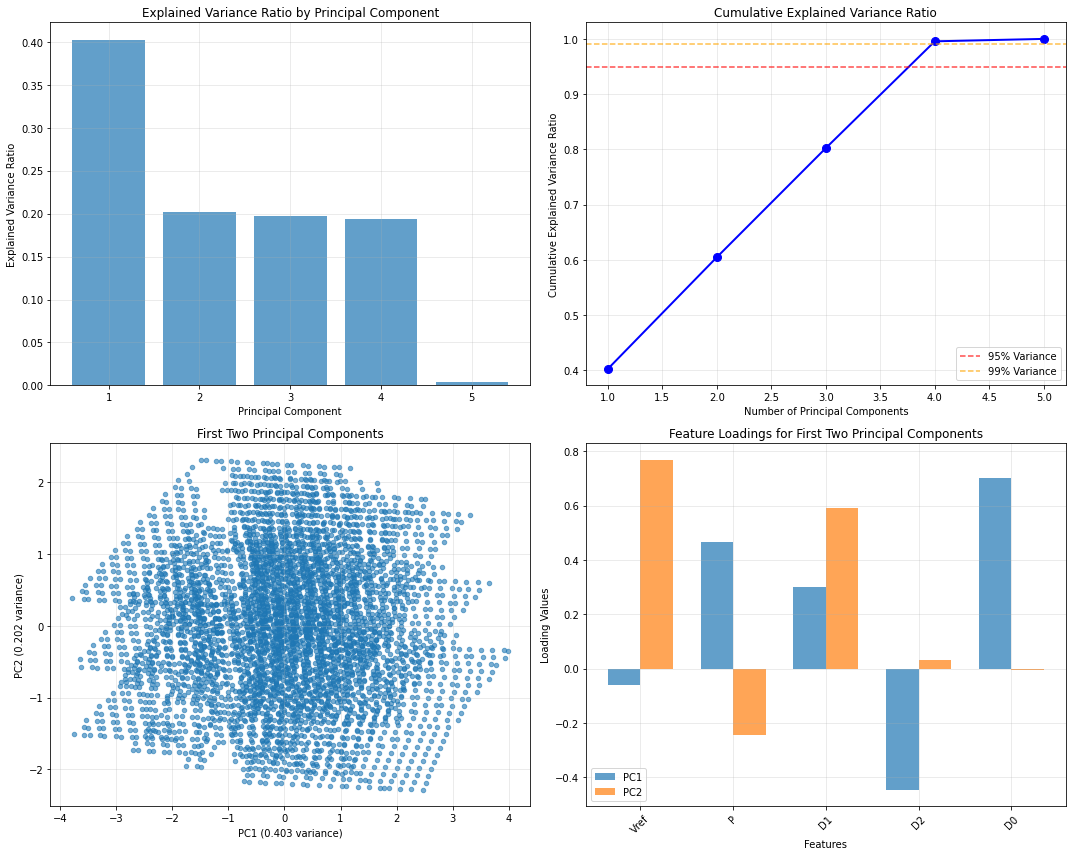

=== PCA ANALYSIS RESULTS ===
Features used: ['Vref', 'P', 'D1', 'D2', 'D0']

Explained variance ratio:
PC1: 0.4025 (40.25%)
PC2: 0.2022 (20.22%)
PC3: 0.1976 (19.76%)
PC4: 0.1933 (19.33%)
PC5: 0.0044 (0.44%)

Cumulative explained variance:
PC1-PC1: 0.4025 (40.25%)
PC1-PC2: 0.6048 (60.48%)
PC1-PC3: 0.8023 (80.23%)
PC1-PC4: 0.9956 (99.56%)
PC1-PC5: 1.0000 (100.00%)

Number of components needed for:
95% variance: 4
99% variance: 4

Feature loadings for PC1:
Vref: -0.0609
P: 0.4644
D1: 0.3015
D2: -0.4455
D0: 0.7009

Feature loadings for PC2:
Vref: 0.7690
P: -0.2454
D1: 0.5895
D2: 0.0316
D0: -0.0040


In [4]:
# Perform PCA on the selected features

# Import necessary modules for PCA and feature scaling
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select the features for PCA analysis
# These features are chosen because they are related and may satisfy a specific equation
pca_features = ["Vref", "P", "D1", "D2", "D0"]
X_pca = df_final[pca_features]

#------------------------------------------------------------------------------------------------
# Conduct PCA analysis
# It is important to standardize the features before applying PCA,
# because PCA is sensitive to the scale of the variables
#------------------------------------------------------------------------------------------------

# Standardize the features so that each has mean=0 and variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Initialize PCA object (number of components defaults to min(n_samples, n_features))
pca = PCA()
# Fit PCA on the standardized data and transform the data to principal component space
X_pca_transformed = pca.fit_transform(X_scaled)

# Calculate the explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
# Calculate the cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Import utility function to plot and summarize PCA results
from utils import plot_and_summarize_pca_results

# Plot and summarize the PCA results using the provided utility function
plot_and_summarize_pca_results(
    explained_variance_ratio,      # Variance explained by each principal component
    cumulative_variance_ratio,     # Cumulative variance explained
    X_pca_transformed,             # Data projected onto principal components
    pca,                           # Fitted PCA object
    pca_features                   # Names of the original features
)


#### 2 Stage 1: Outlier Detection and Data Cleaning with One-Class SVM

C:\Temp/ipykernel_14972/3964881073.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['OCSVM_outlier'] = (y_pred == -1)


Number of outliers detected by One-Class SVM (all features): 235
Sample outliers detected by One-Class SVM (all features):
     Vin  Vref    P   D1    D2        D0  Validity    ipk2pk      irms  vp_t1  \
idx                                                                             
0    200   160  100  0.6  0.60  0.001907         1  6.808841  2.045685      1   
1    200   160  100  0.6  0.62 -0.000407         1  6.168091  1.797907      1   
2    200   160  100  0.6  0.64 -0.020192         1  5.841870  1.627620      1   
6    200   160  100  0.6  0.72 -0.060763         1  5.803701  1.306371      1   
7    200   160  100  0.6  0.74 -0.061512         1  6.427577  1.406230      1   

     vp_t2  vp_t3  vp_t4  vs_t1  vs_t2  vs_t3  vs_t4          Vo  total_ZVS  \
idx                                                                           
0        1      1      1      0      0      0      0  159.896261          4   
1        1      1      1      0      0      0      0  159.954938        

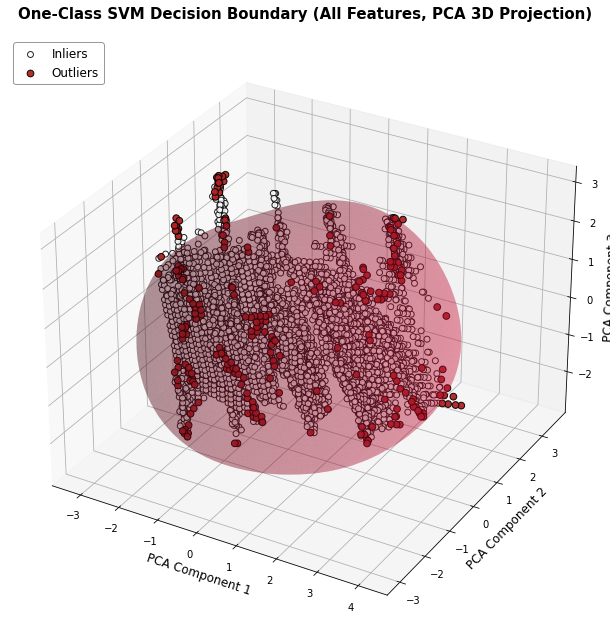

In [5]:
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use all input and output features for outlier detection
input_features = ["Vref", "P", "D1", "D2", "D0"]
output_features = ["ipk2pk", "total_ZVS"]
ocsvm_features = input_features + output_features
X_ocsvm = df_final[ocsvm_features]

# Standardize all features
scaler_all = StandardScaler()
X_ocsvm_scaled = scaler_all.fit_transform(X_ocsvm)

# Initialize One-Class SVM (nu is an upper bound on the fraction of outliers, gamma='auto' is common)
ocsvm = OneClassSVM(nu=0.05, gamma='auto', kernel='rbf')
y_pred = ocsvm.fit_predict(X_ocsvm_scaled)

# Add a column to indicate outliers (-1 means outlier, 1 means inlier)
df_final['OCSVM_outlier'] = (y_pred == -1)

# Print the number of detected outliers
num_outliers = (df_final['OCSVM_outlier']).sum()
print(f"Number of outliers detected by One-Class SVM (all features): {num_outliers}")

# Optionally, show a few outlier samples
print("Sample outliers detected by One-Class SVM (all features):")
print(df_final[df_final['OCSVM_outlier']].head())

# --- Plot the decision boundary in 2D using PCA projection of all features ---

# Reduce all features to 3D using PCA for visualization
from mpl_toolkits.mplot3d import Axes3D

pca_vis_3d = PCA(n_components=3)
X_vis_3d = pca_vis_3d.fit_transform(X_ocsvm_scaled)

# Create a 3D grid in the PCA space
n_grid = 40  # keep this moderate for performance
x_min, x_max = X_vis_3d[:, 0].min() - 0.5, X_vis_3d[:, 0].max() + 0.5
y_min, y_max = X_vis_3d[:, 1].min() - 0.5, X_vis_3d[:, 1].max() + 0.5
z_min, z_max = X_vis_3d[:, 2].min() - 0.5, X_vis_3d[:, 2].max() + 0.5

xx, yy, zz = np.meshgrid(
    np.linspace(x_min, x_max, n_grid),
    np.linspace(y_min, y_max, n_grid),
    np.linspace(z_min, z_max, n_grid)
)
grid_points_pca_3d = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

# Inverse transform grid points to original scaled feature space for OCSVM decision function
grid_points_orig_3d = pca_vis_3d.inverse_transform(grid_points_pca_3d)
Z_3d = ocsvm.decision_function(grid_points_orig_3d)
Z_3d = Z_3d.reshape(xx.shape)

# Plot in 3D
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot inliers and outliers in the PCA 3D space
ax.scatter(
    X_vis_3d[y_pred == 1, 0], X_vis_3d[y_pred == 1, 1], X_vis_3d[y_pred == 1, 2],
    c='white', s=35, edgecolor='k', label='Inliers', alpha=0.85, marker='o'
)
ax.scatter(
    X_vis_3d[y_pred == -1, 0], X_vis_3d[y_pred == -1, 1], X_vis_3d[y_pred == -1, 2],
    c='firebrick', s=45, edgecolor='k', label='Outliers', alpha=0.95, marker='o'
)

# Plot the decision boundary (Z_3d == 0) as an isosurface
# We'll plot a few isosurfaces for better visualization
try:
    from skimage import measure
    # The 0-level isosurface (decision boundary)
    verts, faces, normals, values = measure.marching_cubes(Z_3d, level=0, spacing=(
        (x_max - x_min) / (n_grid - 1),
        (y_max - y_min) / (n_grid - 1),
        (z_max - z_min) / (n_grid - 1)
    ))
    # Shift verts to correct coordinates
    verts[:, 0] += x_min
    verts[:, 1] += y_min
    verts[:, 2] += z_min
    mesh = ax.plot_trisurf(
        verts[:, 0], verts[:, 1], faces, verts[:, 2],
        color='crimson', alpha=0.25, linewidth=0.1, antialiased=True, shade=True
    )
except ImportError:
    print("Install scikit-image for 3D isosurface plotting of the decision boundary.")

ax.set_title("One-Class SVM Decision Boundary (All Features, PCA 3D Projection)", fontsize=15, fontweight='bold', pad=18)
ax.set_xlabel("PCA Component 1", fontsize=12)
ax.set_ylabel("PCA Component 2", fontsize=12)
ax.set_zlabel("PCA Component 3", fontsize=12)
ax.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import IsolationForest

# --- Isolation Forest Outlier Detection (using all features) ---

# Use the same features as before
X_iforest = df_final[ocsvm_features]

# Standardize features (reuse scaler_all if already fit, or fit a new one)
# Here, we reuse scaler_all for consistency
X_iforest_scaled = scaler_all.transform(X_iforest)

# Initialize Isolation Forest
iforest = IsolationForest(contamination=0.05, random_state=42)
y_pred_iforest = iforest.fit_predict(X_iforest_scaled)

# Add a column to indicate outliers (-1 means outlier, 1 means inlier)
df_final['IForest_outlier'] = (y_pred_iforest == -1)

# Print the number of detected outliers
num_outliers_iforest = (df_final['IForest_outlier']).sum()
print(f"Number of outliers detected by Isolation Forest (all features): {num_outliers_iforest}")

# Optionally, show a few outlier samples
print("Sample outliers detected by Isolation Forest (all features):")
print(df_final[df_final['IForest_outlier']].head())

# --- Plot the decision boundary in 2D using PCA projection of all features ---

# Reduce all features to 3D using PCA for visualization (reuse pca_vis_3d if already fit)
X_vis_3d_iforest = pca_vis_3d.transform(X_iforest_scaled)

# Create a 3D grid in the PCA space (reuse previous grid)
# Inverse transform grid points to original scaled feature space for Isolation Forest decision function
grid_points_orig_3d_iforest = pca_vis_3d.inverse_transform(grid_points_pca_3d)
Z_3d_iforest = iforest.decision_function(grid_points_orig_3d_iforest)
Z_3d_iforest = Z_3d_iforest.reshape(xx.shape)

# Plot in 3D
fig_iforest = plt.figure(figsize=(11, 9))
ax_iforest = fig_iforest.add_subplot(111, projection='3d')

# Plot inliers and outliers in the PCA 3D space
ax_iforest.scatter(
    X_vis_3d_iforest[y_pred_iforest == 1, 0], X_vis_3d_iforest[y_pred_iforest == 1, 1], X_vis_3d_iforest[y_pred_iforest == 1, 2],
    c='white', s=35, edgecolor='k', label='Inliers', alpha=0.85, marker='o'
)
ax_iforest.scatter(
    X_vis_3d_iforest[y_pred_iforest == -1, 0], X_vis_3d_iforest[y_pred_iforest == -1, 1], X_vis_3d_iforest[y_pred_iforest == -1, 2],
    c='navy', s=45, edgecolor='k', label='Outliers', alpha=0.95, marker='o'
)

# Plot the decision boundary (Z_3d_iforest == 0) as an isosurface
try:
    from skimage import measure
    verts_if, faces_if, normals_if, values_if = measure.marching_cubes(Z_3d_iforest, level=0, spacing=(
        (x_max - x_min) / (n_grid - 1),
        (y_max - y_min) / (n_grid - 1),
        (z_max - z_min) / (n_grid - 1)
    ))
    verts_if[:, 0] += x_min
    verts_if[:, 1] += y_min
    verts_if[:, 2] += z_min
    mesh_if = ax_iforest.plot_trisurf(
        verts_if[:, 0], verts_if[:, 1], faces_if, verts_if[:, 2],
        color='navy', alpha=0.25, linewidth=0.1, antialiased=True, shade=True
    )
except ImportError:
    print("Install scikit-image for 3D isosurface plotting of the decision boundary.")

ax_iforest.set_title("Isolation Forest Decision Boundary (All Features, PCA 3D Projection)", fontsize=15, fontweight='bold', pad=18)
ax_iforest.set_xlabel("PCA Component 1", fontsize=12)
ax_iforest.set_ylabel("PCA Component 2", fontsize=12)
ax_iforest.set_zlabel("PCA Component 3", fontsize=12)
ax_iforest.legend(
    loc='upper left',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)
ax_iforest.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


#### 3 Stage 2: Data-Driven Performance Modeling with NNs
   1. Neural networks
   2. Benchmark with ensemble learning algorithms

##### 3.1 Neural networks for current stress and soft switching modeling
* Current stress modeling is a regression task
* Soft switching modeling is a classification task

In [6]:
# Define the neural network architecture, implement the training process, and tune the hyper-parameters

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import copy

# =========================
# Configurable flags/params
# =========================
USE_STANDARDIZE = True  # Flag: whether to standardize input features
USE_BATCHNORM = True    # Flag: whether to use batch normalization
USE_ZSCORE_GRAD = True  # Flag: whether to z-score gradients
USE_LR_SCHEDULER = True # Flag: whether to use learning rate scheduler

HIDDEN_SIZE = 32        # Parameter: hidden layer size
NUM_HIDDEN_LAYERS = 2   # Parameter: number of hidden layers

ACTIVATION = "tanh"     # Variable: activation function, options: "relu", "tanh"

# =========================
# Activation function selector
# =========================
def get_activation(name):
    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    else:
        raise ValueError(f"Unknown activation: {name}")

# =========================
# Neural network definition
# =========================
class CurrentStressMLP(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_hidden_layers=2, activation="relu", use_batchnorm=True):
        super(CurrentStressMLP, self).__init__()
        layers = []
        in_dim = input_size
        act = get_activation(activation)
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(act)
            in_dim = hidden_size
        layers.append(nn.Linear(hidden_size, 1))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

# =========================
# Custom dataset class
# =========================
class CurrentStressDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).reshape(-1, 1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# =========================
# Prepare the data
# =========================
input_features = ["P", "Vref", "D1", "D2"]
output_feature = "ipk2pk"

# Extract features and target
X = df_final[input_features].values
y = df_final[output_feature].values

# Split the data: train/val/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Feature scaling or normalization is important for the training of the neural network
if USE_STANDARDIZE:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
else:
    X_train_scaled = X_train
    X_val_scaled = X_val
    X_test_scaled = X_test

# Create datasets and dataloaders
train_dataset = CurrentStressDataset(X_train_scaled, y_train)
val_dataset = CurrentStressDataset(X_val_scaled, y_val)
test_dataset = CurrentStressDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# =========================
# Initialize the model and JIT compile it
# =========================
model_NN_regression = CurrentStressMLP(
    input_size=len(input_features),
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    activation=ACTIVATION,
    use_batchnorm=USE_BATCHNORM
)

# Use torch.jit.script to compile the model for acceleration
model_NN_regression = torch.jit.script(model_NN_regression)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_NN_regression.parameters(), lr=0.1)  # Higher initial learning rate

if USE_LR_SCHEDULER:
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)  # Reduce LR every 200 epochs

# =========================
# Training loop
# =========================
num_epochs = 200
train_losses = []
val_losses = []
test_losses = []  # <--- Add test loss tracking
best_val_loss = float('inf')
best_model_state = None

print("Training the neural network...")
for epoch in range(num_epochs):
    # Training phase
    model_NN_regression.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_NN_regression(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient z-scoring if enabled
        if USE_ZSCORE_GRAD:
            for param in model_NN_regression.parameters():
                if param.grad is not None:
                    grad_mean = param.grad.mean()
                    grad_std = param.grad.std()
                    if grad_std > 0:
                        param.grad = (param.grad - grad_mean) / grad_std
        
        optimizer.step()
        train_loss += loss.item()
    
    # Update learning rate if enabled
    if USE_LR_SCHEDULER:
        scheduler.step()
    
    # Validation phase
    model_NN_regression.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model_NN_regression(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    # Test phase (record test loss)
    test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model_NN_regression(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    test_losses.append(test_loss / len(test_loader))
    
    # Save best model on validation set
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        # For JIT models, state_dict is still supported
        best_model_state = copy.deepcopy(model_NN_regression.state_dict())
    
    if (epoch + 1) % 20 == 0:
        if USE_LR_SCHEDULER:
            current_lr = scheduler.get_last_lr()[0]
        else:
            current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {current_lr:.6f}, Train Loss: {train_losses[-1]:.6f}, Val Loss: {val_losses[-1]:.6f}, Test Loss: {test_losses[-1]:.6f}')

# Load best model weights (on validation set)
if best_model_state is not None:
    model_NN_regression.load_state_dict(best_model_state)

Training the neural network...


C:\Temp/ipykernel_14972/2034391330.py:153: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1808.)
  grad_std = param.grad.std()


Epoch [20/200], LR: 0.100000, Train Loss: 0.652607, Val Loss: 0.840924, Test Loss: 0.913460
Epoch [40/200], LR: 0.050000, Train Loss: 0.960484, Val Loss: 0.632140, Test Loss: 0.649186
Epoch [60/200], LR: 0.050000, Train Loss: 0.269825, Val Loss: 0.214479, Test Loss: 0.215566
Epoch [80/200], LR: 0.025000, Train Loss: 0.303665, Val Loss: 0.269769, Test Loss: 0.271838
Epoch [100/200], LR: 0.025000, Train Loss: 0.208105, Val Loss: 0.190484, Test Loss: 0.197792
Epoch [120/200], LR: 0.012500, Train Loss: 0.378921, Val Loss: 0.277937, Test Loss: 0.293772
Epoch [140/200], LR: 0.012500, Train Loss: 0.206869, Val Loss: 0.181348, Test Loss: 0.185726
Epoch [160/200], LR: 0.006250, Train Loss: 0.187244, Val Loss: 0.162363, Test Loss: 0.161572
Epoch [180/200], LR: 0.006250, Train Loss: 0.189308, Val Loss: 0.165034, Test Loss: 0.171024
Epoch [200/200], LR: 0.003125, Train Loss: 0.171701, Val Loss: 0.166067, Test Loss: 0.167661



[RBF SVM Regression] Test set results:
  MSE:  0.197862
  RMSE: 0.444817
  R^2:  0.993157


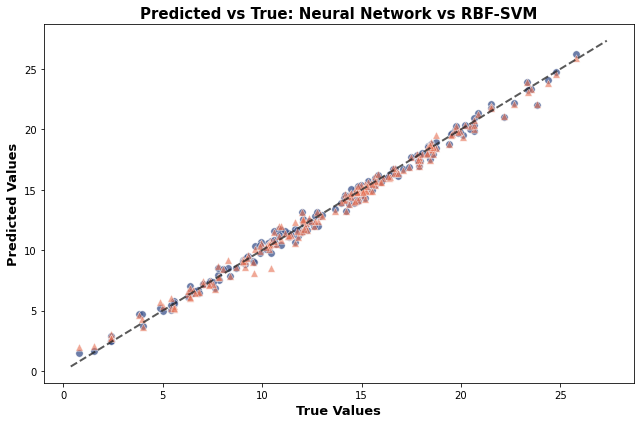

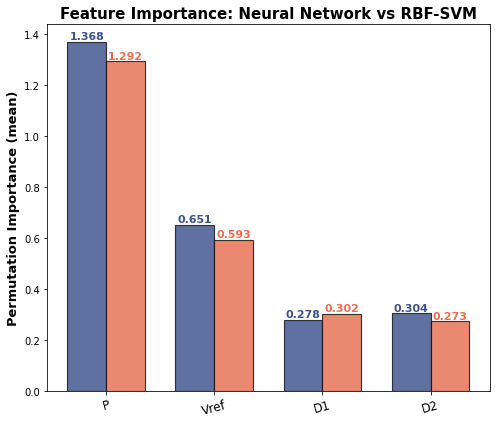

In [7]:
#------------------------------------------------------------------------------------------------
# RBF-based SVM Regression & Comparison Plot with Neural Network

from sklearn.svm import SVR

# --- Train an RBF (Radial Basis Function) SVM regressor ---
svm_regressor = SVR(kernel='rbf', C=10.0, epsilon=0.2)
svm_regressor.fit(X_train_scaled, y_train)

# --- Evaluate on test set ---
y_pred_svm = svm_regressor.predict(X_test_scaled)

# --- Calculate performance metrics ---
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("\n[RBF SVM Regression] Test set results:")
print(f"  MSE:  {mse_svm:.6f}")
print(f"  RMSE: {rmse_svm:.6f}")
print(f"  R^2:  {r2_svm:.6f}")

# --- Neural network predictions for test set ---
with torch.no_grad():
    y_pred_nn = model_NN_regression(torch.FloatTensor(X_test_scaled)).detach().cpu().numpy().flatten()

# --- Pretty plot: Predicted vs True values for NN and RBF-SVM (Nature style) ---
plt.figure(figsize=(9, 6))
# Nature color palette
color_nn = "#3B528B"      # blue-violet, for Neural Network
color_svm = "#E76F51"     # reddish, for SVM
identity_line = "#222222" # dark, for y=x

# Plot only a random subset (e.g., 200 points) of test data for clearer visualization
subset_size = min(200, len(y_test))
subset_indices = np.random.choice(len(y_test), size=subset_size, replace=False)

plt.scatter(y_test[subset_indices], y_pred_nn[subset_indices], color=color_nn, alpha=0.75, label="Neural Network",
            edgecolor='#FFFFFF', s=55, marker='o', linewidth=0.6)
plt.scatter(y_test[subset_indices], y_pred_svm[subset_indices], color=color_svm, alpha=0.60, label="RBF-SVM",
            edgecolor='#FFFFFF', s=55, marker="^", linewidth=0.6)

lims = [min(y_test.min(), y_pred_nn.min(), y_pred_svm.min()), max(y_test.max(), y_pred_nn.max(), y_pred_svm.max())]
plt.plot(lims, lims, '--', alpha=0.75, lw=2, color=identity_line, label="Ideal (y=x)")

plt.xlabel('True Values', fontsize=13, fontweight='semibold')
plt.ylabel('Predicted Values', fontsize=13, fontweight='semibold')
plt.title('Predicted vs True: Neural Network vs RBF-SVM', fontsize=15, weight='bold')
# plt.legend(fontsize=12, loc='upper left', frameon=True, facecolor='#F8F5F0')
plt.tight_layout()
plt.show()

# --- Permutation Feature Importances: SVM and Neural Network (using native NN permutation method) ---

from sklearn.metrics import r2_score

def nn_permutation_importance(model, X, y, feature_names):
    base_score = r2_score(y, model(torch.FloatTensor(X)).detach().cpu().numpy().flatten())
    importance_scores = []
    for i in range(X.shape[1]):
        X_permuted = X.copy()
        np.random.shuffle(X_permuted[:, i])
        permuted_score = r2_score(y, model(torch.FloatTensor(X_permuted)).detach().cpu().numpy().flatten())
        importance_scores.append(base_score - permuted_score)
    return np.array(importance_scores)

# SVM importances
from sklearn.inspection import permutation_importance
perm_importance_svm = permutation_importance(
    svm_regressor, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='r2'
)
importances_svm = perm_importance_svm.importances_mean

# Neural network importances (native, robust)
try:
    importances_nn = nn_permutation_importance(
        model_NN_regression, X_test_scaled, y_test, input_features
    )
    models_for_plot = [
        ("Neural Network", importances_nn, color_nn),
        ("RBF-SVM", importances_svm, color_svm)
    ]
    feature_labels = input_features
except Exception as e:
    print("Permutation importance failed for NN, only showing SVM importances.")
    models_for_plot = [("RBF-SVM", importances_svm, color_svm)]
    feature_labels = input_features

# Nature-ready bar plot
plt.figure(figsize=(7, 6))
bar_width = 0.36
x = np.arange(len(feature_labels))

for i, (label, importances, color) in enumerate(models_for_plot):
    plt.bar(x + i * bar_width, importances, width=bar_width, label=label, 
            color=color, alpha=0.82, edgecolor='#111111', linewidth=1.15)
    for xi, yi in zip(x + i*bar_width, importances):
        plt.text(xi, yi + 0.001, f"{yi:.3f}", ha="center", va="bottom", fontsize=11, 
                 color=color, fontweight="bold")

plt.xticks(
    x + bar_width / 2 * (len(models_for_plot) - 1),
    feature_labels,
    fontsize=12, fontweight='medium', rotation=15)
plt.ylabel("Permutation Importance (mean)", fontsize=13, fontweight='semibold')
plt.title("Feature Importance: Neural Network vs RBF-SVM", fontsize=15, weight='bold')
# plt.legend(fontsize=12, frameon=True, loc="upper right", facecolor='#F8F5F0')
plt.tight_layout()
plt.show()


=== MODEL PERFORMANCE ===
Mean Squared Error: 0.158967
Root Mean Squared Error: 0.398707
R² Score: 0.994502


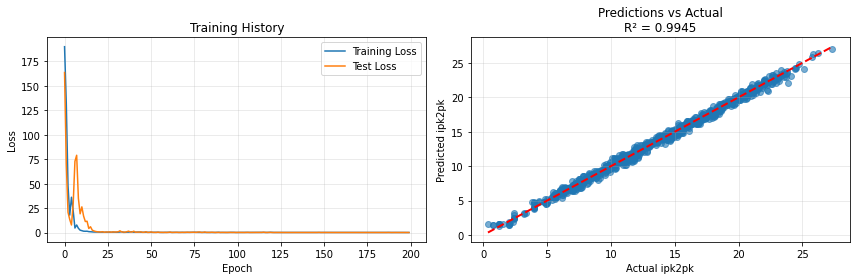

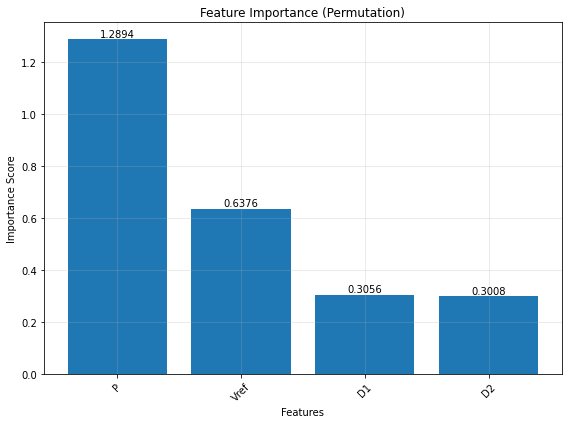


=== FEATURE IMPORTANCE ===
P: 1.289442
Vref: 0.637623
D1: 0.305557
D2: 0.300821


In [8]:
# Evaluate the model
model_NN_regression.eval()
with torch.no_grad():
    y_pred = model_NN_regression(torch.FloatTensor(X_test_scaled)).numpy().flatten()

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

#------------------------------------------------------------------------------------------------
# Plot and report the model performance
#------------------------------------------------------------------------------------------------
from utils import plot_and_report_model_performance

plot_and_report_model_performance(
    mse, rmse, r2,
    train_losses, test_losses,
    y_test, y_pred,
    model_NN_regression, X_test_scaled, input_features
)


=== 3D MESH PLOT ===
Generating 3D mesh plot of current stress vs D1 and D2 (P=100, Vref=240)...


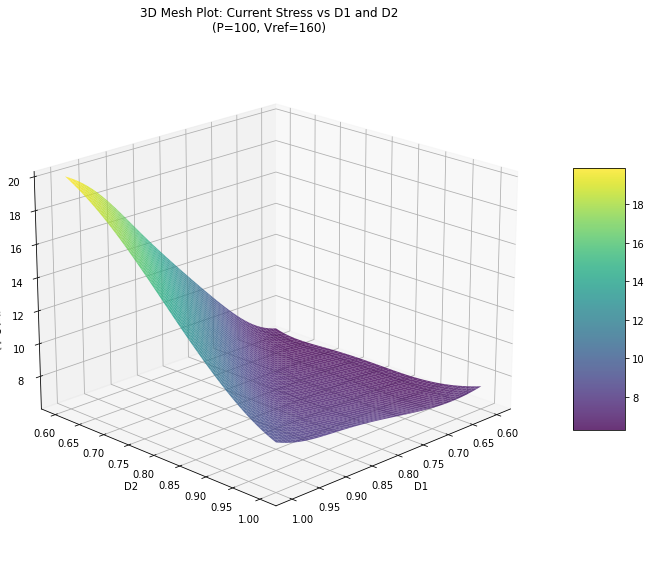

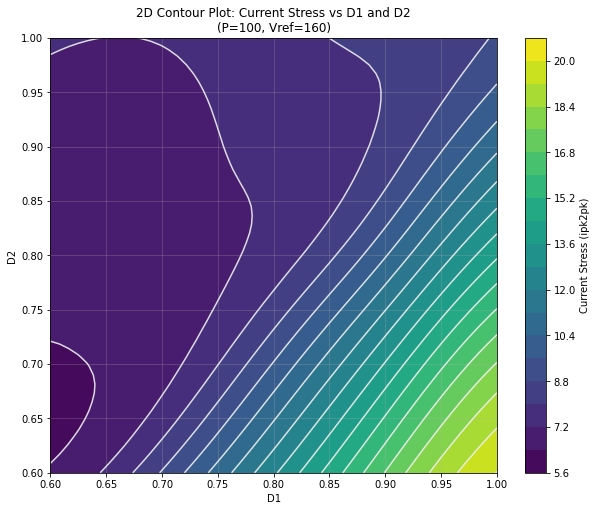

In [9]:
# 3D Mesh plot of current stress with respect to D1 and D2
print(f"\n=== 3D MESH PLOT ===")
print("Generating 3D mesh plot of current stress vs D1 and D2 (P=100, Vref=240)...")

# Create meshgrid for D1 and D2
D1_range = np.linspace(X_test_scaled[:, 2].min(), X_test_scaled[:, 2].max(), 50)  # D1 is at index 2
D2_range = np.linspace(X_test_scaled[:, 3].min(), X_test_scaled[:, 3].max(), 50)  # D2 is at index 3
D1_mesh, D2_mesh = np.meshgrid(D1_range, D2_range)

# Fixed values for P and Vref (scaled)
P_fixed = 100
Vref_fixed = 160

# Transform the fixed values using the same scaler
P_scaled = scaler.transform([[P_fixed, 0, 0, 0]])[0, 0]  # Get P value
Vref_scaled = scaler.transform([[0, Vref_fixed, 0, 0]])[0, 1]  # Get Vref value

#------------------------------------------------------------------------------------------------
# Create a 3D mesh plot of the current stress vs D1 and D2
#------------------------------------------------------------------------------------------------

# Create input array for prediction
X_contour = np.zeros((D1_mesh.size, 4))
X_contour[:, 0] = P_scaled  # P (fixed) - index 0
X_contour[:, 1] = Vref_scaled  # Vref (fixed) - index 1
X_contour[:, 2] = D1_mesh.flatten()  # D1 - index 2
X_contour[:, 3] = D2_mesh.flatten()  # D2 - index 3

# Predict current stress
model_NN_regression.eval()
with torch.no_grad():
    stress_pred = model_NN_regression(torch.FloatTensor(X_contour)).numpy().flatten()

# Reshape predictions back to meshgrid shape
stress_mesh = stress_pred.reshape(D1_mesh.shape)

# Inverse transform D1 and D2 back to original scale
D1_original = np.zeros((D1_mesh.size, 4))
D1_original[:, 2] = D1_mesh.flatten()  # Set D1 values
D1_original = scaler.inverse_transform(D1_original)
D1_original = D1_original[:, 2].reshape(D1_mesh.shape)


D2_original = np.zeros((D2_mesh.size, 4))
D2_original[:, 3] = D2_mesh.flatten()  # Set D2 values
D2_original = scaler.inverse_transform(D2_original)
D2_original = D2_original[:, 3].reshape(D2_mesh.shape)

#------------------------------------------------------------------------------------------------
# Plot the 3D mesh and 2D contour plot of the current stress
#------------------------------------------------------------------------------------------------
from utils import plot_stress_mesh_and_contour

plot_stress_mesh_and_contour(D1_original, D2_original, stress_mesh, 
                                 mesh_title=f'3D Mesh Plot: Current Stress vs D1 and D2\n(P={P_fixed}, Vref={Vref_fixed})', 
                                 contour_title=f'2D Contour Plot: Current Stress vs D1 and D2\n(P={P_fixed}, Vref={Vref_fixed})')

In [10]:
#------------------------------------------------------------------------------------------------
# Define the neural network architecture, implement the training process, and tune the hyper-parameters
#------------------------------------------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import copy

# =========================
# Configurable flags/params
# =========================
USE_STANDARDIZE = True  # Flag: whether to standardize input features
USE_BATCHNORM = True    # Flag: whether to use batch normalization
USE_ZSCORE_GRAD = True  # Flag: whether to z-score gradients
USE_LR_SCHEDULER = True # Flag: whether to use learning rate scheduler

HIDDEN_SIZE = 32        # Parameter: hidden layer size
NUM_HIDDEN_LAYERS = 2   # Parameter: number of hidden layers

ACTIVATION = "tanh"     # Variable: activation function, options: "relu", "tanh"

# =========================
# Activation function selector
# =========================
def get_activation(name):
    if name == "relu":
        return nn.ReLU()
    elif name == "tanh":
        return nn.Tanh()
    else:
        raise ValueError(f"Unknown activation: {name}")

# =========================
# Neural network definition for ZVS classification
# =========================
class ZVSClassificationMLP(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_hidden_layers=2, activation="relu", use_batchnorm=True, num_classes=3):
        super(ZVSClassificationMLP, self).__init__()
        layers = []
        in_dim = input_size
        act = get_activation(activation)
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(act)
            in_dim = hidden_size
        layers.append(nn.Linear(hidden_size, num_classes))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

# =========================
# Custom dataset class for ZVS classification
# =========================
class ZVSClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        # Map 4->0, 6->1, 8->2 for 3 classes (0,1,2)
        self.map_y = {4: 0, 6: 1, 8: 2}
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        y_value = self.y[idx].item()
        return self.X[idx], self.map_y[y_value]

# =========================
# Prepare the data
# =========================
input_features = ["P", "Vref", "D1", "D2"]
output_feature = "total_ZVS"

# Extract features and target
X = df_final[input_features].values
y = df_final[output_feature].values

# Split the data: train/val/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Feature scaling or normalization is important for the training of the neural network
if USE_STANDARDIZE:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
else:
    X_train_scaled = X_train
    X_val_scaled = X_val
    X_test_scaled = X_test

# Create datasets and dataloaders
train_dataset = ZVSClassificationDataset(X_train_scaled, y_train)
val_dataset = ZVSClassificationDataset(X_val_scaled, y_val)
test_dataset = ZVSClassificationDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# =========================
# Initialize the model
# =========================
num_classes = len(np.unique([4, 6, 8]))  # Always 3 for this problem
model_NN_classification = ZVSClassificationMLP(
    input_size=len(input_features),
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    activation=ACTIVATION,
    use_batchnorm=USE_BATCHNORM,
    num_classes=num_classes
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_NN_classification.parameters(), lr=0.1)  # Higher initial learning rate

if USE_LR_SCHEDULER:
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)  # Reduce LR every 200 epochs

# =========================
# Training loop
# =========================
num_epochs = 300
train_losses = []
val_losses = []
test_losses = []
best_val_loss = float('inf')
best_model_state = None

print("Training the ZVS classification neural network...")
for epoch in range(num_epochs):
    # Training phase
    model_NN_classification.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_NN_classification(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        # Gradient z-scoring if enabled
        if USE_ZSCORE_GRAD:
            for param in model_NN_classification.parameters():
                if param.grad is not None:
                    grad_mean = param.grad.mean()
                    grad_std = param.grad.std()
                    if grad_std > 0:
                        param.grad = (param.grad - grad_mean) / grad_std
        
        optimizer.step()
        train_loss += loss.item()
    
    # Update learning rate if enabled
    if USE_LR_SCHEDULER:
        scheduler.step()
    
    # Validation phase
    model_NN_classification.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model_NN_classification(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    # Test phase (track test loss)
    test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model_NN_classification(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    test_losses.append(test_loss / len(test_loader))
    
    # Save best model on validation set
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_model_state = copy.deepcopy(model_NN_classification.state_dict())
    
    if (epoch + 1) % 20 == 0:
        if USE_LR_SCHEDULER:
            current_lr = scheduler.get_last_lr()[0]
        else:
            current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}], LR: {current_lr:.6f}, Train Loss: {train_losses[-1]:.6f}, Val Loss: {val_losses[-1]:.6f}, Test Loss: {test_losses[-1]:.6f}')

# Load best model weights (on validation set)
if best_model_state is not None:
    model_NN_classification.load_state_dict(best_model_state)

Training the ZVS classification neural network...
Epoch [20/300], LR: 0.100000, Train Loss: 0.158091, Val Loss: 0.554326, Test Loss: 0.487592
Epoch [40/300], LR: 0.050000, Train Loss: 0.116812, Val Loss: 0.159718, Test Loss: 0.165358
Epoch [60/300], LR: 0.050000, Train Loss: 0.082185, Val Loss: 0.143187, Test Loss: 0.140336
Epoch [80/300], LR: 0.025000, Train Loss: 0.067218, Val Loss: 0.147490, Test Loss: 0.142170
Epoch [100/300], LR: 0.025000, Train Loss: 0.061684, Val Loss: 0.108947, Test Loss: 0.120015
Epoch [120/300], LR: 0.012500, Train Loss: 0.060199, Val Loss: 0.109839, Test Loss: 0.117387
Epoch [140/300], LR: 0.012500, Train Loss: 0.075998, Val Loss: 0.096714, Test Loss: 0.108755
Epoch [160/300], LR: 0.006250, Train Loss: 0.056306, Val Loss: 0.090552, Test Loss: 0.109982
Epoch [180/300], LR: 0.006250, Train Loss: 0.050918, Val Loss: 0.092461, Test Loss: 0.112788
Epoch [200/300], LR: 0.003125, Train Loss: 0.057488, Val Loss: 0.090514, Test Loss: 0.110020
Epoch [220/300], LR: 0.0


=== ZVS CLASSIFICATION MODEL PERFORMANCE ===
Accuracy: 0.963323
Precision: 0.963157
Recall: 0.963323
F1-Score: 0.963133


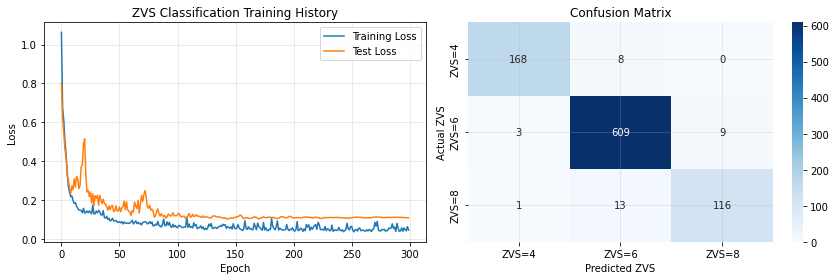

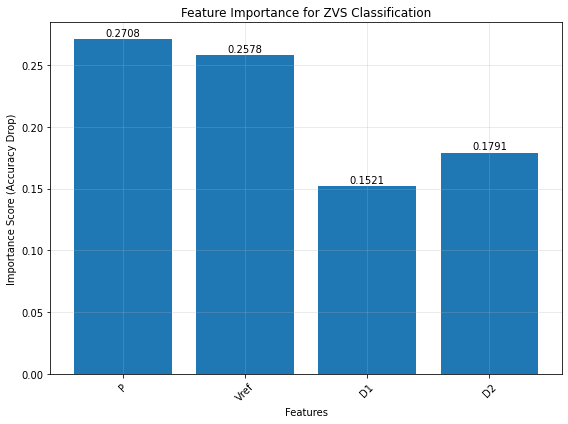


=== FEATURE IMPORTANCE FOR ZVS CLASSIFICATION ===
P: 0.270766
Vref: 0.257821
D1: 0.152104
D2: 0.179072

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       ZVS=4       0.98      0.95      0.97       176
       ZVS=6       0.97      0.98      0.97       621
       ZVS=8       0.93      0.89      0.91       130

    accuracy                           0.96       927
   macro avg       0.96      0.94      0.95       927
weighted avg       0.96      0.96      0.96       927



In [11]:
# Import required metrics from sklearn
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Evaluate the ZVS classification model
model_NN_classification.eval()
with torch.no_grad():
    y_pred_probs = model_NN_classification(torch.FloatTensor(X_test_scaled))
    y_pred_classes = torch.argmax(y_pred_probs, dim=1).numpy()

# Apply the same mapping to y_test as used in the dataset
map_y = {4: 0, 6: 1, 8: 2}  # Map 4->0, 6->1, 8->2 for 3 classes (0,1,2)
y_test_mapped = np.array([map_y[y] for y in y_test])

# Calculate classification metrics
accuracy = accuracy_score(y_test_mapped, y_pred_classes)
precision = precision_score(y_test_mapped, y_pred_classes, average='weighted')
recall = recall_score(y_test_mapped, y_pred_classes, average='weighted')
f1 = f1_score(y_test_mapped, y_pred_classes, average='weighted')

print(f"\n=== ZVS CLASSIFICATION MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-Score: {f1:.6f}")

#------------------------------------------------------------------------------------------------
# Plot the classification results
#------------------------------------------------------------------------------------------------
from utils import plot_classification_results

plot_classification_results(
    train_losses,
    test_losses,
    y_test_mapped,
    y_pred_classes,
    model_NN_classification,
    X_test_scaled,
    input_features
)



=== 2D ZVS CLASSIFICATION PLOT ===
Generating 2D plot of ZVS classification vs D1 and D2 (P=100, Vref=240)...


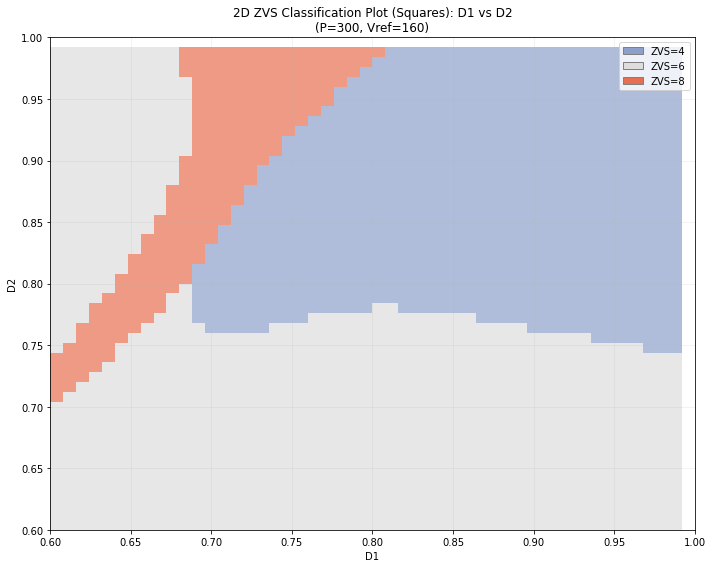

In [12]:
print(f"\n=== 2D ZVS CLASSIFICATION PLOT ===")
print("Generating 2D plot of ZVS classification vs D1 and D2 (P=100, Vref=240)...")

#------------------------------------------------------------------------------------------------
# Create a 2D plot of ZVS classification with respect to the meshgrid of D1 and D2
#------------------------------------------------------------------------------------------------

# Create meshgrid for D1 and D2
D1_range = np.linspace(X_test_scaled[:, 2].min(), X_test_scaled[:, 2].max(), 50)  # D1 is at index 2
D2_range = np.linspace(X_test_scaled[:, 3].min(), X_test_scaled[:, 3].max(), 50)  # D2 is at index 3
D1_mesh, D2_mesh = np.meshgrid(D1_range, D2_range)

# Fixed values for P and Vref (scaled)
P_fixed = 300
Vref_fixed = 160

# Transform the fixed values using the same scaler
P_scaled = scaler.transform([[P_fixed, 0, 0, 0]])[0, 0]  # Get P value
Vref_scaled = scaler.transform([[0, Vref_fixed, 0, 0]])[0, 1]  # Get Vref value

# Create input array for prediction
X_contour = np.zeros((D1_mesh.size, 4))
X_contour[:, 0] = P_scaled  # P (fixed) - index 0
X_contour[:, 1] = Vref_scaled  # Vref (fixed) - index 1
X_contour[:, 2] = D1_mesh.flatten()  # D1 - index 2
X_contour[:, 3] = D2_mesh.flatten()  # D2 - index 3

# Predict ZVS classification
model_NN_classification.eval()
with torch.no_grad():
    zvs_pred = torch.argmax(model_NN_classification(torch.FloatTensor(X_contour)), dim=1).numpy()

# Reshape predictions back to meshgrid shape
zvs_mesh = zvs_pred.reshape(D1_mesh.shape)

# Inverse transform D1 and D2 back to original scale
D1_original = np.zeros((D1_mesh.size, 4))
D1_original[:, 2] = D1_mesh.flatten()  # Set D1 values
D1_original = scaler.inverse_transform(D1_original)
D1_original = D1_original[:, 2].reshape(D1_mesh.shape)

D2_original = np.zeros((D2_mesh.size, 4))
D2_original[:, 3] = D2_mesh.flatten()  # Set D2 values
D2_original = scaler.inverse_transform(D2_original)
D2_original = D2_original[:, 3].reshape(D2_mesh.shape)

#------------------------------------------------------------------------------------------------
# Plot the 2D ZVS classification plot
#------------------------------------------------------------------------------------------------
from utils import plot_2d_zvs_classification

# plot the 2D ZVS classification plot
plot_2d_zvs_classification(D1_original, D2_original, zvs_mesh, P_fixed, Vref_fixed)

##### 3.3 XGBoost for current stress and soft switching modeling

d:\Anaconda\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


Training the XGBoost model...
[20:36:55] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.0/src/learner.cc:576: 
Parameters: { "early_stopping_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[0]	validation_0-rmse:12.24305
[1]	validation_0-rmse:11.07945
[2]	validation_0-rmse:10.03318
[3]	validation_0-rmse:9.14278
[4]	validation_0-rmse:8.35329
[5]	validation_0-rmse:7.57752
[6]	validation_0-rmse:6.94471
[7]	validation_0-rmse:6.32698
[8]	validation_0-rmse:5.77468
[9]	validation_0-rmse:5.26018
[10]	validation_0-rmse:4.81679
[11]	validation_0-rmse:4.40309
[12]	validation_0-rmse:4.04682
[13]	validation_0-rmse:3.73570
[14]	validation_0-rmse:3.46394
[15]	validation_0-rmse:3.22613
[16]	validation_0-rmse:2.99555
[17]	validation_0-rm

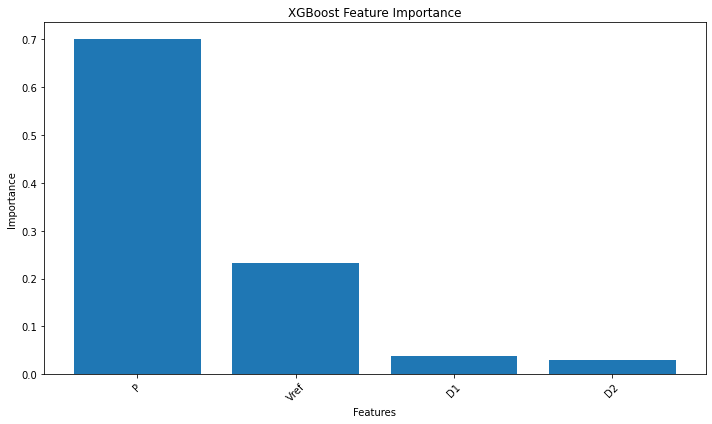

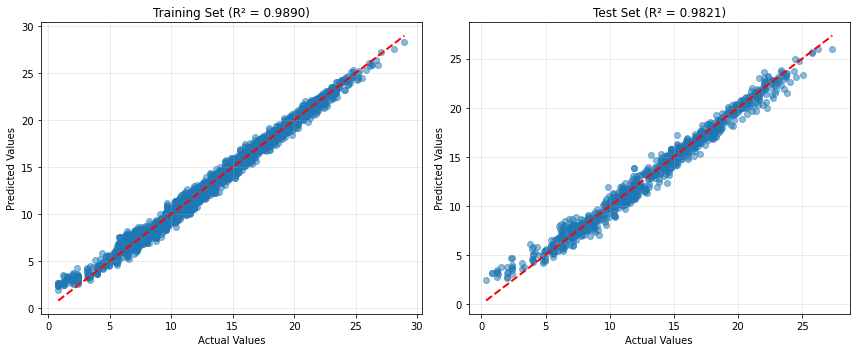


=== 3D MESH PLOT (XGBoost) ===
Generating 3D mesh plot of current stress vs D1 and D2 (P=100, Vref=160)...


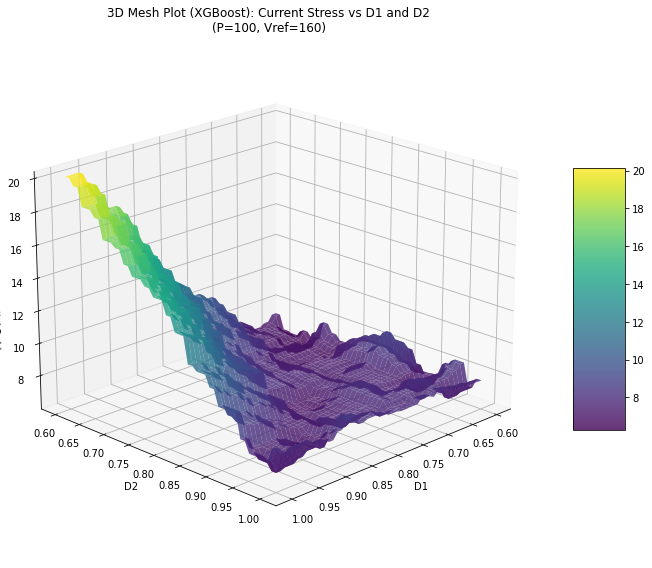

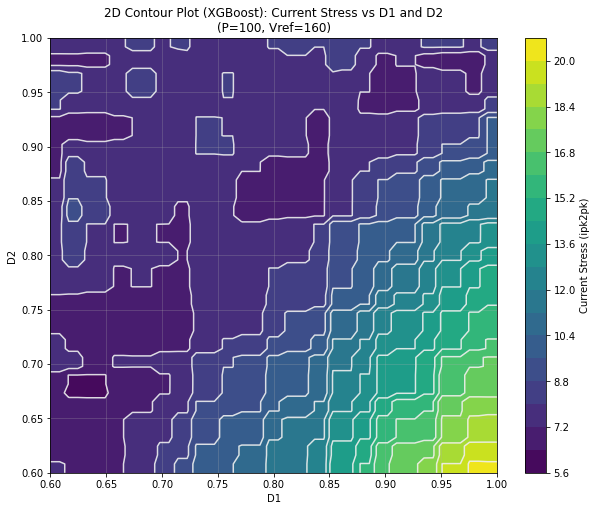

In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Prepare the data
input_features = ["P", "Vref", "D1", "D2"]
output_feature = "ipk2pk"

# Extract features and target
X = df_final[input_features].values
y = df_final[output_feature].values

# Split the data: first train+val/test, then train/val
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

#------------------------------------------------------------------------------------------------
# Use XGBoost to predict the current stress, do NOT scale the features
#------------------------------------------------------------------------------------------------

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

# Training the XGBoost model with early stopping on validation set
print("Training the XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# Make predictions
y_train_pred = xgb_model.predict(X_train)
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nXGBoost Results:")
print(f"Train MSE: {train_mse:.6f}")
print(f"Val MSE:   {val_mse:.6f}")
print(f"Test MSE:  {test_mse:.6f}")
print(f"Train R²: {train_r2:.6f}")
print(f"Val R²:   {val_r2:.6f}")
print(f"Test R²:  {test_r2:.6f}")

# Feature importance
feature_importance = xgb_model.feature_importances_
feature_names = input_features

#------------------------------------------------------------------------------------------------
# Plot the feature importance and predictions
#------------------------------------------------------------------------------------------------
from utils import plot_xgboost_feature_importance_and_predictions

plot_xgboost_feature_importance_and_predictions(
    feature_names=feature_names,
    feature_importance=feature_importance,
    y_train=y_train,
    y_train_pred=y_train_pred,
    train_r2=train_r2,
    y_test=y_test,
    y_test_pred=y_test_pred,
    test_r2=test_r2
)

# ---------------- Adjusted for XGBoost mesh/contour ----------------
# 3D Mesh plot of current stress with respect to D1 and D2 using XGBoost
print(f"\n=== 3D MESH PLOT (XGBoost) ===")
print("Generating 3D mesh plot of current stress vs D1 and D2 (P=100, Vref=160)...")

# Create meshgrid for D1 and D2 using the original (unscaled) ranges in X (since XGBoost is unscaled)
D1_min, D1_max = X[:, 2].min(), X[:, 2].max()
D2_min, D2_max = X[:, 3].min(), X[:, 3].max()
D1_range = np.linspace(D1_min, D1_max, 50)
D2_range = np.linspace(D2_min, D2_max, 50)
D1_mesh, D2_mesh = np.meshgrid(D1_range, D2_range)

# Fixed values for P and Vref (original scale)
P_fixed = 100
Vref_fixed = 160

# Create input array for prediction (same shape as mesh)
X_contour = np.zeros((D1_mesh.size, 4))
X_contour[:, 0] = P_fixed    # P (fixed) - index 0
X_contour[:, 1] = Vref_fixed # Vref (fixed) - index 1
X_contour[:, 2] = D1_mesh.flatten() # D1 - index 2
X_contour[:, 3] = D2_mesh.flatten() # D2 - index 3

# Predict current stress using XGBoost
stress_pred_xgb = xgb_model.predict(X_contour)

# Reshape predictions back to meshgrid shape
stress_mesh_xgb = stress_pred_xgb.reshape(D1_mesh.shape)

# The axes (D1, D2) are already in original values; no scaling/inverse transformation needed

# Optionally import your mesh and contour plotting function
from utils import plot_stress_mesh_and_contour

plot_stress_mesh_and_contour(
    D1_mesh, D2_mesh, stress_mesh_xgb, 
    mesh_title=f'3D Mesh Plot (XGBoost): Current Stress vs D1 and D2\n(P={P_fixed}, Vref={Vref_fixed})', 
    contour_title=f'2D Contour Plot (XGBoost): Current Stress vs D1 and D2\n(P={P_fixed}, Vref={Vref_fixed})'
)


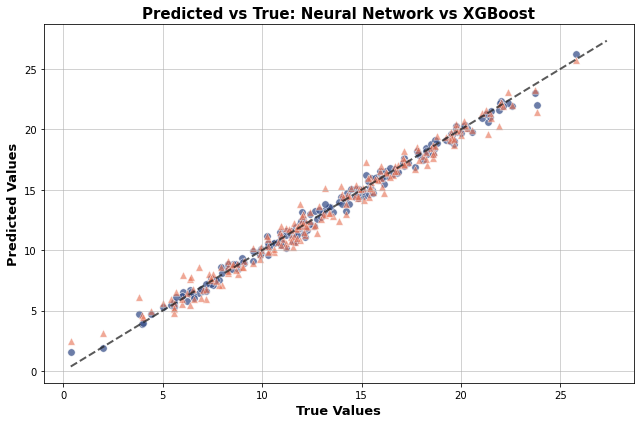

In [14]:
# --- Pretty plot: Predicted vs True values for NN and XGBoost (Nature style) ---
plt.figure(figsize=(9, 6))
# Nature color palette
color_nn = "#3B528B"      # blue-violet, for Neural Network
color_xgboost = "#E76F51"     # reddish, for XGBoost
identity_line = "#222222" # dark, for y=x

# Plot only a random subset (e.g., 200 points) of test data for clearer visualization
subset_size = min(200, len(y_test))
subset_indices = np.random.choice(len(y_test), size=subset_size, replace=False)

plt.scatter(y_test[subset_indices], y_pred[subset_indices], color=color_nn, alpha=0.75, label="Neural Network",
            edgecolor='#FFFFFF', s=55, marker='o', linewidth=0.6)
plt.scatter(y_test[subset_indices], y_test_pred[subset_indices], color=color_xgboost, alpha=0.60, label="XGBoost",
            edgecolor='#FFFFFF', s=55, marker="^", linewidth=0.6)

lims = [min(y_test.min(), y_pred.min(), y_test_pred.min()), max(y_test.max(), y_pred.max(), y_test_pred.max())]
plt.plot(lims, lims, '--', alpha=0.75, lw=2, color=identity_line, label="Ideal (y=x)")

plt.xlabel('True Values', fontsize=13, fontweight='semibold')
plt.ylabel('Predicted Values', fontsize=13, fontweight='semibold')
plt.title('Predicted vs True: Neural Network vs XGBoost', fontsize=15, weight='bold')
# plt.legend(fontsize=12, loc='upper left', frameon=True, facecolor='#F8F5F0')
plt.tight_layout()
plt.grid(True, alpha=0.7)
plt.show()


In [15]:
# Print the model sizes (number of tunable parameters) for both NN and XGBoost (current stress regression)

# Neural Network: count number of trainable parameters
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

nn_num_params = count_trainable_params(model_NN_regression)
print(f"Neural Network (Current Stress) - Number of tunable parameters: {nn_num_params}")

# XGBoost: estimate number of tunable parameters
# For XGBoost, the number of parameters is not as straightforward as NN, but we can estimate as:
# Number of trees * average number of leaves per tree (each leaf has a weight)
# We'll sum the number of leaves in all trees
booster = xgb_model.get_booster()
num_trees = len(booster.get_dump())
num_leaves = 0
for tree in booster.get_dump(with_stats=True):
    # Each line with "leaf=" is a leaf node
    num_leaves += tree.count("leaf=")
print(f"XGBoost (Current Stress) - Number of tunable parameters (total leaves across all trees): {num_leaves}")


Neural Network (Current Stress) - Number of tunable parameters: 1377
XGBoost (Current Stress) - Number of tunable parameters (total leaves across all trees): 4821


Training the ZVS classification XGBoost model...
[20:37:38] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.0/src/learner.cc:576: 
Parameters: { "early_stopping_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[0]	validation_0-merror:0.07875
[1]	validation_0-merror:0.07875
[2]	validation_0-merror:0.08091
[3]	validation_0-merror:0.07443
[4]	validation_0-merror:0.07012
[5]	validation_0-merror:0.06904
[6]	validation_0-merror:0.07120
[7]	validation_0-merror:0.06904
[8]	validation_0-merror:0.06688
[9]	validation_0-merror:0.06688
[10]	validation_0-merror:0.06688
[11]	validation_0-merror:0.06580
[12]	validation_0-merror:0.06473
[13]	validation_0-merror:0.06688
[14]	validation_0-merror:0.06580
[15]	validation_0-merror:0.06365
[16

d:\Anaconda\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[18]	validation_0-merror:0.05933
[19]	validation_0-merror:0.05717
[20]	validation_0-merror:0.05825
[21]	validation_0-merror:0.05933
[22]	validation_0-merror:0.05609
[23]	validation_0-merror:0.05502
[24]	validation_0-merror:0.05394
[25]	validation_0-merror:0.05502
[26]	validation_0-merror:0.05286
[27]	validation_0-merror:0.05178
[28]	validation_0-merror:0.05178
[29]	validation_0-merror:0.05178
[30]	validation_0-merror:0.05178
[31]	validation_0-merror:0.04962
[32]	validation_0-merror:0.04962
[33]	validation_0-merror:0.04962
[34]	validation_0-merror:0.04962
[35]	validation_0-merror:0.04962
[36]	validation_0-merror:0.04854
[37]	validation_0-merror:0.04962
[38]	validation_0-merror:0.04962
[39]	validation_0-merror:0.04962
[40]	validation_0-merror:0.05070
[41]	validation_0-merror:0.05070
[42]	validation_0-merror:0.04962
[43]	validation_0-merror:0.05178
[44]	validation_0-merror:0.05070
[45]	validation_0-merror:0.05178
[46]	validation_0-merror:0.05178
[47]	validation_0-merror:0.05178
[48]	valid

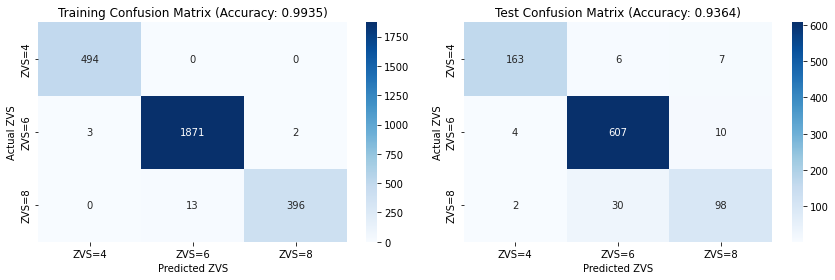

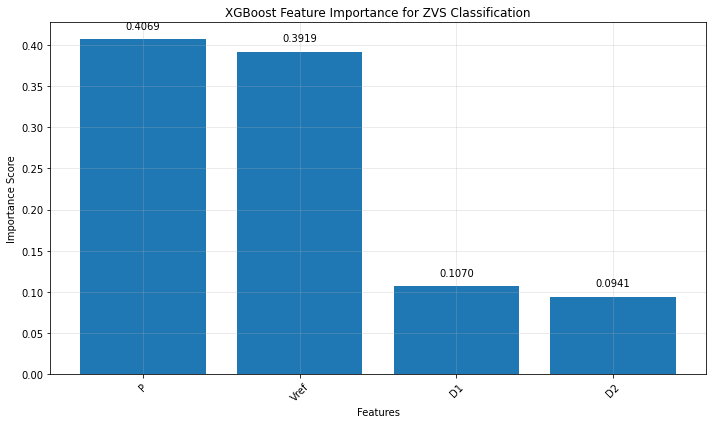


=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       ZVS=4       0.96      0.93      0.94       176
       ZVS=6       0.94      0.98      0.96       621
       ZVS=8       0.85      0.75      0.80       130

    accuracy                           0.94       927
   macro avg       0.92      0.89      0.90       927
weighted avg       0.94      0.94      0.93       927


=== FEATURE IMPORTANCE FOR ZVS CLASSIFICATION ===
P: 0.406942
Vref: 0.391909
D1: 0.107043
D2: 0.094106


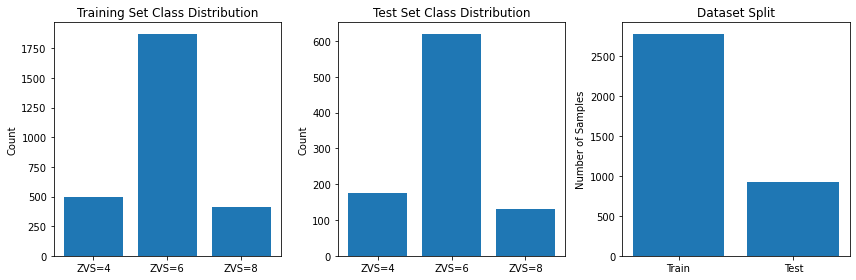


=== DATASET SUMMARY ===
Training samples: 2779
Test samples: 927
Total samples: 3706
Number of classes: 3


In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for ZVS classification
input_features = ["P", "Vref", "D1", "D2"]
output_feature = "total_ZVS"

# Extract features and target
X = df_final[input_features].values
y = df_final[output_feature].values

# Create mapping for ZVS classes
map_y = {4: 0, 6: 1, 8: 2}  # Map 4->0, 6->1, 8->2 for 3 classes (0,1,2)
y_mapped = np.array([map_y[y_val] for y_val in y])

# Split the data: first train+val/test, then train/val (same as regression)
X_temp, X_test, y_temp, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

# Initialize and train XGBoost classifier with early stopping on validation set, no scaling
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    random_state=42,
    eval_metric='merror',
    early_stopping_rounds=5,
)

print("Training the ZVS classification XGBoost model...")
xgb_classifier.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

# Make predictions
y_train_pred = xgb_classifier.predict(X_train)
y_val_pred = xgb_classifier.predict(X_val)
y_test_pred = xgb_classifier.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\n=== XGBOOST ZVS CLASSIFICATION RESULTS ===")
print(f"Training Accuracy: {train_accuracy:.6f}")
print(f"Validation Accuracy: {val_accuracy:.6f}")
print(f"Test Accuracy: {test_accuracy:.6f}")

#------------------------------------------------------------------------------------------------
# Plot the classification results
#------------------------------------------------------------------------------------------------
from utils import classification_analysis

classification_analysis(
    y_train, y_train_pred, train_accuracy,
    y_test, y_test_pred, test_accuracy,
    xgb_classifier, input_features,
    y_mapped
)


#### 4 Stage 3: Meta-Heuristic Algorithms to Optimize Converter Performances
   1. Particle swarm optimization
   2. Genetic algorithm

##### 4.1 Implement PSO

In [17]:
#------------------------------------------------------------------------------------------------
# Implement the PSO algorithm to search within D1 and D2 ranges given P and Vref values
#------------------------------------------------------------------------------------------------

import pyswarms as ps
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Set fixed parameters
P_fixed = 300
Vref_fixed = 160

# Define D1 and D2 bounds
d1_min, d1_max = 0.6, 1.0
d2_min, d2_max = 0.6, 1.0
bounds = (np.array([d1_min, d2_min]), np.array([d1_max, d2_max]))

# Velocity bounds: 40% of the range for each dimension
vmax = 0.4 * (bounds[1] - bounds[0])
vmin = -vmax
velocity_clamp = (vmin, vmax)

# PSO options: c1 and c2 to 2.05, w will be changed from 0.9 to 0.0 during operation
options = {'c1': 0.3, 'c2': 0.7, 'w': 0.9}

n_particles = 10
dimensions = 2
n_iters = 100

# Latin Hypercube Initialization for Swarm Positions
def latin_hypercube_sampling(n_samples, bounds, random_state=None):
    lower, upper = np.array(bounds[0]), np.array(bounds[1])
    dim = len(lower)
    cut = np.linspace(0, 1, n_samples + 1)
    if random_state is not None:
        rng = np.random.RandomState(random_state)
        u = rng.rand(n_samples, dim)
    else:
        u = np.random.rand(n_samples, dim)
    a = cut[:n_samples]
    b = cut[1:n_samples+1]
    rdpoints = np.zeros_like(u)
    for j in range(dim):
        rdpoints[:, j] = u[:, j] * (b - a) + a
        if random_state is not None:
            rng.shuffle(rdpoints[:, j])
        else:
            np.random.shuffle(rdpoints[:, j])
    samples = lower + rdpoints * (upper - lower)
    return samples

init_pos = latin_hypercube_sampling(
    n_particles,
    ([d1_min, d2_min], [d1_max, d2_max]),
    random_state=RANDOM_SEED
)

# To record all costs (and constraints, current stress) at every iteration
all_particle_costs = []      # shape: (n_iters, n_particles)
all_constraint_violations = []  # shape: (n_iters, n_particles)
all_current_stresses = []    # shape: (n_iters, n_particles)

def objective(X):
    n_particles = X.shape[0]
    costs = np.zeros(n_particles)
    current_stresses = np.zeros(n_particles)
    constraint_violations = np.zeros(n_particles, dtype=int)
    for i in range(n_particles):
        D1, D2 = X[i, 0], X[i, 1]
        X_input = np.array([[P_fixed, Vref_fixed, D1, D2]])
        X_input_scaled = scaler.transform(X_input)
        X_input_tensor = torch.FloatTensor(X_input_scaled)
        model_NN_regression.eval()
        model_NN_classification.eval()
        with torch.no_grad():
            current_stress = model_NN_regression(X_input_tensor).squeeze().item()
            zvs_output = model_NN_classification(X_input_tensor)
            zvs_prediction_idx = torch.argmax(zvs_output, dim=1).item()
            zvs_mapping = {0: 4, 1: 6, 2: 8}
            zvs_prediction = zvs_mapping[zvs_prediction_idx]
        violation = int(zvs_prediction != 8)
        penalty = violation * 1000
        current_stresses[i] = current_stress
        constraint_violations[i] = violation
        costs[i] = current_stress + penalty
    # Store for later analysis
    all_particle_costs.append(costs.copy())
    all_constraint_violations.append(constraint_violations.copy())
    all_current_stresses.append(current_stresses.copy())
    return costs

optimizer = ps.single.GlobalBestPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    options=options,
    bounds=bounds,
    velocity_clamp=velocity_clamp,
    init_pos=init_pos
)

cost_history = []
pos_history = []
swarm_history = []
velocity_history = []

w_start = 0.9
w_end = 0.1

for i in range(n_iters):
    # Linearly interpolate w
    if i <= n_iters-50:
        w = w_start + (w_end - w_start) * (i / ((n_iters-50) - 1))
    else:
        w = w_end
    optimizer.options['w'] = w
    optimizer.optimize(objective, iters=1, verbose=False)
    cost_history.append(optimizer.swarm.best_cost)
    pos_history.append(optimizer.swarm.best_pos.copy())
    swarm_history.append(optimizer.swarm.position.copy())
    velocity_history.append(optimizer.swarm.velocity.copy())

best_cost = optimizer.swarm.best_cost
best_pos = optimizer.swarm.best_pos

print("Best cost:", best_cost)
print("Best position:", best_pos)

# Save all-particle-per-iteration logs as numpy arrays for further analysis or plotting
all_particle_costs = np.array(all_particle_costs)               # shape: (n_iters, n_particles)
all_constraint_violations = np.array(all_constraint_violations) # shape: (n_iters, n_particles)
all_current_stresses = np.array(all_current_stresses)           # shape: (n_iters, n_particles)

print("Shape of all_particle_costs array:", all_particle_costs.shape)
print("Shape of all_constraint_violations array:", all_constraint_violations.shape)
print("Shape of all_current_stresses array:", all_current_stresses.shape)

Best cost: 9.522564888000488
Best position: [0.60668632 0.75269863]
Shape of all_particle_costs array: (100, 10)
Shape of all_constraint_violations array: (100, 10)
Shape of all_current_stresses array: (100, 10)


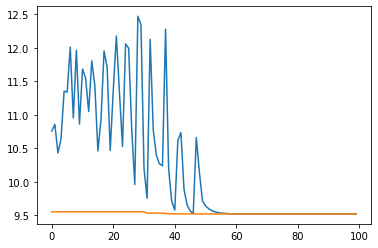

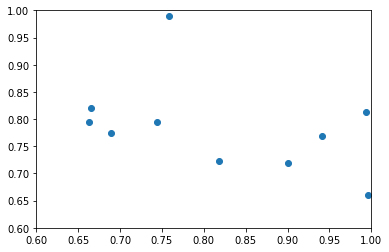

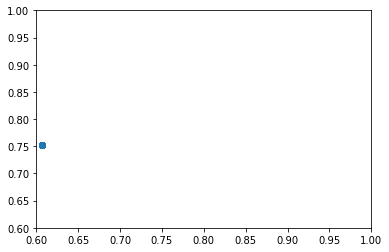

In [18]:
plt.plot(np.mean(all_current_stresses, axis=1))
plt.plot(cost_history)
plt.show()

plt.scatter(swarm_history[9][:, 0], swarm_history[9][:, 1])
plt.xlim([0.6, 1])
plt.ylim([0.6, 1])
plt.show()

plt.scatter(swarm_history[89][:, 0], swarm_history[89][:, 1])
plt.xlim([0.6, 1])
plt.ylim([0.6, 1])
plt.show()

In [ ]:
#------------------------------------------------------------------------------------------------
# Plot the optimization results as an animated GIF in the 2D D1-D2 space with current stress contours
#------------------------------------------------------------------------------------------------

import matplotlib.cm as cm
import imageio

# Prepare a grid for contour plot
D1_grid = np.linspace(0.6, 1.0, 100)
D2_grid = np.linspace(0.6, 1.0, 100)
D1_mesh, D2_mesh = np.meshgrid(D1_grid, D2_grid)
current_stress_grid = np.zeros_like(D1_mesh)

# Compute current stress (no penalty) for the grid
for i in range(D1_mesh.shape[0]):
    for j in range(D1_mesh.shape[1]):
        D1 = D1_mesh[i, j]
        D2 = D2_mesh[i, j]
        X_input = np.array([[P_fixed, Vref_fixed, D1, D2]])
        X_input_scaled = scaler.transform(X_input)
        X_input_tensor = torch.FloatTensor(X_input_scaled)
        model_NN_regression.eval()
        with torch.no_grad():
            current_stress = model_NN_regression(X_input_tensor).squeeze().item()
        current_stress_grid[i, j] = current_stress

# Normalize for colorbar
vmin = np.min(current_stress_grid)
vmax = np.max(current_stress_grid)

# Prepare to save frames
frames = []
fig, ax = plt.subplots(figsize=(10, 8))

for iter_idx, swarm_pos in enumerate(swarm_history):
    ax.clear()
    # Plot contour
    contour = ax.contourf(D1_mesh, D2_mesh, current_stress_grid, levels=30, cmap=cm.viridis, vmin=vmin, vmax=vmax)
    # Plot swarm positions
    ax.scatter(swarm_pos[:, 0], swarm_pos[:, 1], c='red', s=40, label='Particles')
    # Plot global best so far
    ax.scatter(pos_history[iter_idx][0], pos_history[iter_idx][1], c='yellow', s=100, marker='*', label='Global Best')
    ax.set_xlim(0.6, 1.0)
    ax.set_ylim(0.6, 1.0)
    ax.set_xlabel('D1')
    ax.set_ylabel('D2')
    ax.set_title(f'PSO Search Iteration {iter_idx+1}/{n_iters}')
    if iter_idx == 0:
        cbar = fig.colorbar(contour, ax=ax, shrink=0.8)
        cbar.set_label('Current Stress')
    ax.legend(loc='upper right')
    # Save frame to buffer
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(image.copy())

plt.close(fig)
# Save as GIF (make it loop/recurring)
# imageio.mimsave('pso_searching_process.gif', frames, fps=5, loop=0)  # loop=0 means infinite loop

#------------------------------------------------------------------------------------------------
# Evaluate the best solution
#------------------------------------------------------------------------------------------------
X_best = np.array([[P_fixed, Vref_fixed, best_pos[0], best_pos[1]]])
X_best_scaled = scaler.transform(X_best)
X_best_tensor = torch.FloatTensor(X_best_scaled)

model_NN_regression.eval()
model_NN_classification.eval()
with torch.no_grad():
    best_current_stress = model_NN_regression(X_best_tensor).item()
    best_zvs_prediction = model_NN_classification(X_best_tensor).argmax(dim=1).item()
    zvs_mapping = {0: 4, 1: 6, 2: 8}
    best_zvs_prediction = zvs_mapping[best_zvs_prediction]

print(f"Optimized current stress: {best_current_stress:.4f}")
print(f"Target ZVS devices: {best_zvs_prediction}")
print(f"Best D1: {best_pos[0]:.4f}, Best D2: {best_pos[1]:.4f}")
# print("PSO searching process saved as 'pso_searching_process.gif'.")

##### 4.2 Enumerate the PSO throughout the Entire Operating Conditions

In [19]:
# Optimize for different power and voltage levels

# Define the voltage and power levels to sweep
Vref_list = [160, 180, 200, 220, 240]
P_list = list(range(100, 1001, 100))  # 100, 200, ..., 1000

# Store results in a list of dicts
optimization_results = []

for Vref in Vref_list:
    for P in P_list:
        # Define a new objective function for this P and Vref
        def objective_function_sweep(positions):
            n_particles = positions.shape[0]
            costs = np.zeros(n_particles)
            for i in range(n_particles):
                D1, D2 = positions[i, 0], positions[i, 1]
                X_input = np.array([[P, Vref, D1, D2]])
                X_input_scaled = scaler.transform(X_input)
                X_input_tensor = torch.FloatTensor(X_input_scaled)
                model_NN_regression.eval()
                model_NN_classification.eval()
                with torch.no_grad():
                    current_stress = model_NN_regression(X_input_tensor).squeeze().item()
                    zvs_output = model_NN_classification(X_input_tensor)
                    zvs_prediction = torch.argmax(zvs_output, dim=1).item()
                    zvs_mapping = {0: 4, 1: 6, 2: 8}
                    zvs_prediction = zvs_mapping[zvs_prediction]
                zvs_penalty = abs(zvs_prediction - 8) * 1000
                costs[i] = current_stress + zvs_penalty
            return costs

        # Re-initialize PSO optimizer for each sweep (to avoid state carryover)
        optimizer_sweep = ps.single.GlobalBestPSO(
            n_particles=20,
            dimensions=2,
            options=options.copy(),
            bounds=([0.6, 0.6], [1, 1]),
            init_pos=None
        )

        cost_history_sweep = []
        pos_history_sweep = []
        c1_start = 2.05
        c2_start = 2.05
        c1_end = 2.05
        c2_end = 2.05
        for i in range(n_iters):
            w = w_start - (w_start - w_end) * (i / (n_iters - 1))
            c1 = c1_start - (c1_start - c1_end) * (i / (n_iters - 1))
            c2 = c2_start + (c2_end - c2_start) * (i / (n_iters - 1))
            optimizer_sweep.options['w'] = w
            optimizer_sweep.options['c1'] = c1
            optimizer_sweep.options['c2'] = c2
            cost, pos = optimizer_sweep.optimize(objective_function_sweep, iters=1, verbose=False)
            cost_history_sweep.append(cost)
            pos_history_sweep.append(pos)
        best_cost = cost_history_sweep[-1]
        best_pos = pos_history_sweep[-1]
        # Save results: Vref, P, D1, D2
        optimization_results.append({
            'Vref': Vref,
            'P': P,
            'D1': best_pos[0],
            'D2': best_pos[1]
        })
        print(f"Vref: {Vref}, P: {P}, D1: {best_pos[0]}, D2: {best_pos[1]}")

# Convert results to a DataFrame for easier analysis
import pandas as pd
df_optimization_results = pd.DataFrame(optimization_results)
df_optimization_results.to_csv("optimization_results.csv", index=False)



Vref: 160, P: 100, D1: 0.6097279121585374, D2: 0.7573947885773504
Vref: 160, P: 200, D1: 0.6282057006641283, D2: 0.8633830304494414
Vref: 160, P: 300, D1: 0.6848265928860783, D2: 0.924317536231222
Vref: 160, P: 400, D1: 0.7245798780394558, D2: 0.9617176856509105
Vref: 160, P: 500, D1: 0.7819181597734682, D2: 0.9476522832136804
Vref: 160, P: 600, D1: 0.8920896112332399, D2: 0.9773741286563892
Vref: 160, P: 700, D1: 0.9069971416457221, D2: 0.9708448957642584


KeyboardInterrupt: 

##### 4.3 Implement GA

300 160


d:\Anaconda\lib\site-packages\pygad\pygad.py:748: UserWarning: The percentage of genes to mutate (mutation_percent_genes=20) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")
d:\Anaconda\lib\site-packages\pygad\pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after e

[pygad] Optimized current stress: 9.5164
[pygad] Target ZVS devices: 8
[pygad] Optimized positions: D1 = 0.6985, D2 = 0.9225


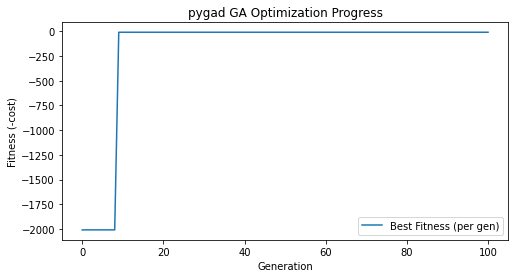

In [20]:
import pygad
import imageio

# --- To record all statistics at each generation ---
ga_population_history = []    # Each element: population positions (shape: (pop, 2))
ga_fitness_history = []       # Each element: fitness values for the population (shape: (pop,))
ga_current_stress_history = []
ga_zvs_penalty_history = []

# Also save all populations, including initial and all generations
ga_all_populations = []       # Each element: population positions (shape: (pop, 2))

# Define the fitness function for pygad (to be maximized, so return negative cost)
def pygad_fitness_func(ga_instance, solution, solution_idx):
    D1, D2 = solution
    X_input = np.array([[P_fixed, Vref_fixed, D1, D2]])
    X_input_scaled = scaler.transform(X_input)
    X_input_tensor = torch.FloatTensor(X_input_scaled)
    model_NN_regression.eval()
    model_NN_classification.eval()
    with torch.no_grad():
        current_stress = model_NN_regression(X_input_tensor).squeeze().item()
        zvs_output = model_NN_classification(X_input_tensor)
        zvs_prediction = torch.argmax(zvs_output, dim=1).item()
        zvs_mapping = {0: 4, 1: 6, 2: 8}
        zvs_prediction = zvs_mapping[zvs_prediction]
    zvs_penalty = abs(zvs_prediction - 8) * 1000
    cost = current_stress + zvs_penalty
    # For statistics collection during the callback
    if hasattr(ga_instance, "__collect_stats") and ga_instance.__collect_stats:
        # This is only relevant when called during population evaluation, not for single solutions
        if ga_instance.__collect_pop_idx < len(ga_instance.__collect_curr_stress):
            ga_instance.__collect_curr_stress[ga_instance.__collect_pop_idx] = current_stress
            ga_instance.__collect_zvs_penalty[ga_instance.__collect_pop_idx] = zvs_penalty
            # fitness is -cost (pygad maximizes fitness)
            ga_instance.__collect_fitness[ga_instance.__collect_pop_idx] = -cost
            ga_instance.__collect_pop_idx += 1
    return -cost  # pygad maximizes fitness

print(P_fixed, Vref_fixed)

# Parameter bounds for D1 and D2
gene_space = [
    {'low': 0.6, 'high': 1.0},  # D1
    {'low': 0.6, 'high': 1.0}   # D2
]

# GA parameters (similar to PSO settings)
num_generations = 100
num_parents_mating = 5
sol_per_pop = 10
num_genes = 2

# Custom callback to record population positions & their fitness & breakdown
def on_generation(ga_instance):
    # Save a copy of the current population (positions)
    ga_population_history.append(ga_instance.population.copy())
    ga_all_populations.append(ga_instance.population.copy())
    # Init arrays to collect values during fitness evaluation of current pop
    pop_size = ga_instance.population.shape[0]
    # Set up temporary attributes used by fitness function
    ga_instance.__collect_stats = True  # flag so fitness knows to record
    ga_instance.__collect_pop_idx = 0
    ga_instance.__collect_curr_stress = np.zeros(pop_size)
    ga_instance.__collect_zvs_penalty = np.zeros(pop_size)
    ga_instance.__collect_fitness = np.zeros(pop_size)
    # Evaluate the fitness of the population (this will fill stats via the fitness fn)
    _ = [pygad_fitness_func(ga_instance, sol, idx) for idx, sol in enumerate(ga_instance.population)]
    # Record stats for this generation
    ga_current_stress_history.append(ga_instance.__collect_curr_stress.copy())
    ga_zvs_penalty_history.append(ga_instance.__collect_zvs_penalty.copy())
    ga_fitness_history.append(ga_instance.__collect_fitness.copy())
    # Clean up temporary attributes
    del ga_instance.__collect_stats
    del ga_instance.__collect_pop_idx
    del ga_instance.__collect_curr_stress
    del ga_instance.__collect_zvs_penalty
    del ga_instance.__collect_fitness

# Build GA instance
ga_instance = pygad.GA(
    num_generations=num_generations,
    num_parents_mating=num_parents_mating,
    fitness_func=pygad_fitness_func,
    sol_per_pop=sol_per_pop,
    num_genes=num_genes,
    gene_space=gene_space,
    parent_selection_type="sss",
    keep_parents=2,
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    on_generation=on_generation
)

# Save initial population before running (and also compute stats for it)
ga_population_history.append(ga_instance.initial_population.copy())
ga_all_populations.append(ga_instance.initial_population.copy())
# For initial pop, create and use dummy GA instance to collect stats
class DummyGAInstance(object): pass
init_stats = DummyGAInstance()
init_stats.population = ga_instance.initial_population.copy()
init_stats.__collect_stats = True
init_stats.__collect_pop_idx = 0
init_stats.__collect_curr_stress = np.zeros(sol_per_pop)
init_stats.__collect_zvs_penalty = np.zeros(sol_per_pop)
init_stats.__collect_fitness = np.zeros(sol_per_pop)
_ = [pygad_fitness_func(init_stats, sol, i) for i, sol in enumerate(init_stats.population)]
ga_current_stress_history.append(init_stats.__collect_curr_stress.copy())
ga_zvs_penalty_history.append(init_stats.__collect_zvs_penalty.copy())
ga_fitness_history.append(init_stats.__collect_fitness.copy())

ga_instance.run()

# Get the best solution
solution, solution_fitness, solution_idx = ga_instance.best_solution()
best_D1, best_D2 = solution

# Evaluate the best solution
X_best_ga = np.array([[P_fixed, Vref_fixed, best_D1, best_D2]])
X_best_ga_scaled = scaler.transform(X_best_ga)
X_best_ga_tensor = torch.FloatTensor(X_best_ga_scaled)

model_NN_regression.eval()
model_NN_classification.eval()
with torch.no_grad():
    best_current_stress_ga = model_NN_regression(X_best_ga_tensor).item()
    best_zvs_prediction_ga = model_NN_classification(X_best_ga_tensor).argmax(dim=1).item()
    zvs_mapping = {0: 4, 1: 6, 2: 8}
    best_zvs_prediction_ga = zvs_mapping[best_zvs_prediction_ga]

print(f"[pygad] Optimized current stress: {best_current_stress_ga:.4f}")
print(f"[pygad] Target ZVS devices: {best_zvs_prediction_ga}")
print(f"[pygad] Optimized positions: D1 = {best_D1:.4f}, D2 = {best_D2:.4f}")

# Plot the fitness over generations
plt.figure(figsize=(8,4))
plt.plot(ga_instance.best_solutions_fitness, label="Best Fitness (per gen)")
plt.xlabel("Generation")
plt.ylabel("Fitness (-cost)")
plt.title("pygad GA Optimization Progress")
plt.legend()
plt.show()

# Now, ga_all_populations is a list of all population positions at initial and all generations
# Example use:
#   for i, pop in enumerate(ga_all_populations):
#       # pop is (n_pop, 2) array at generation i (i = 0 for initial population)

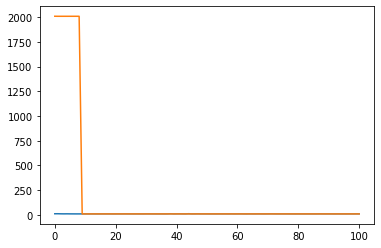

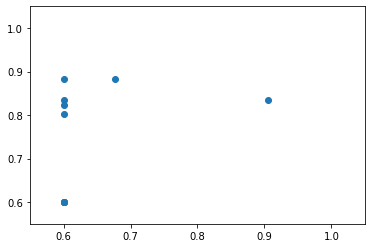

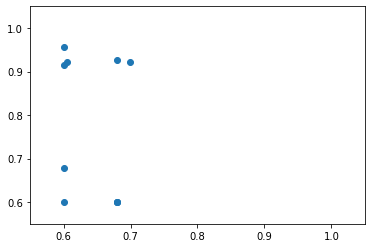

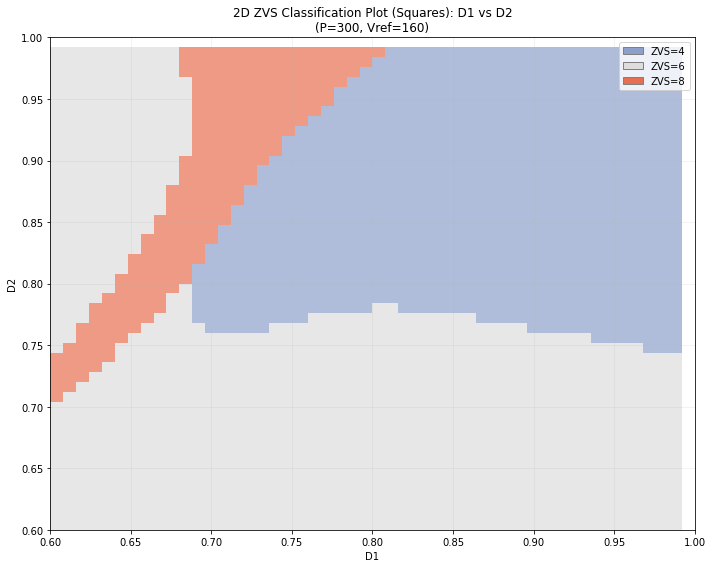

In [22]:
plt.plot(np.mean(ga_current_stress_history, axis=1))
plt.plot(-np.array(ga_instance.best_solutions_fitness))
plt.show()

plt.scatter(ga_all_populations[9][:, 0], ga_all_populations[9][:, 1])
plt.xlim([0.55, 1.05])
plt.ylim([0.55, 1.05])
plt.show()

plt.scatter(ga_all_populations[89][:, 0], ga_all_populations[89][:, 1])
plt.xlim([0.55, 1.05])
plt.ylim([0.55, 1.05])
plt.show()


plot_2d_zvs_classification(D1_original, D2_original, zvs_mesh, P_fixed, Vref_fixed)
# plot_stress_mesh_and_contour(D1_original, D2_original, stress_mesh, 
#                                  mesh_title=f'3D Mesh Plot: Current Stress vs D1 and D2\n(P={P_fixed}, Vref={Vref_fixed})', 
#                                  contour_title=f'2D Contour Plot: Current Stress vs D1 and D2\n(P={P_fixed}, Vref={Vref_fixed})')

In [ ]:
# -------------------------------
# Animate the GA search process
# -------------------------------

# Prepare a grid for contour plot (reuse from PSO section)
D1_grid = np.linspace(0.6, 1.0, 100)
D2_grid = np.linspace(0.6, 1.0, 100)
D1_mesh, D2_mesh = np.meshgrid(D1_grid, D2_grid)
current_stress_grid = np.zeros_like(D1_mesh)

# Compute current stress (no penalty) for the grid
for i in range(D1_mesh.shape[0]):
    for j in range(D1_mesh.shape[1]):
        D1 = D1_mesh[i, j]
        D2 = D2_mesh[i, j]
        X_input = np.array([[P_fixed, Vref_fixed, D1, D2]])
        X_input_scaled = scaler.transform(X_input)
        X_input_tensor = torch.FloatTensor(X_input_scaled)
        model_NN_regression.eval()
        with torch.no_grad():
            current_stress = model_NN_regression(X_input_tensor).squeeze().item()
        current_stress_grid[i, j] = current_stress

vmin = np.min(current_stress_grid)
vmax = np.max(current_stress_grid)

frames = []
fig, ax = plt.subplots(figsize=(10, 8))

for gen_idx, pop in enumerate(ga_population_history):
    ax.clear()
    # Plot contour
    contour = ax.contourf(D1_mesh, D2_mesh, current_stress_grid, levels=30, cmap=cm.viridis, vmin=vmin, vmax=vmax)
    # Plot population
    ax.scatter(pop[:, 0], pop[:, 1], c='red', s=40, label='Population')
    # Plot best so far
    if gen_idx < len(ga_instance.best_solutions):
        best_sol = ga_instance.best_solutions[gen_idx]
        ax.scatter(best_sol[0], best_sol[1], c='yellow', s=100, marker='*', label='Best So Far')
    ax.set_xlim(0.6, 1.0)
    ax.set_ylim(0.6, 1.0)
    ax.set_xlabel('D1')
    ax.set_ylabel('D2')
    ax.set_title(f'GA Search Generation {gen_idx+1}/{len(ga_population_history)}')
    if gen_idx == 0:
        cbar = fig.colorbar(contour, ax=ax, shrink=0.8)
        cbar.set_label('Current Stress')
    ax.legend(loc='upper right')
    # Save frame to buffer
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(image.copy())

plt.close(fig)
# Save as GIF
# imageio.mimsave('ga_searching_process.gif', frames, fps=5)
# print("GA searching process saved as 'ga_searching_process.gif'.")